<a href="https://colab.research.google.com/github/JMCVALE/ASN-ROCKS-/blob/main/SERIES_TEMPORAIS_Previs%C3%A3o_de_Vendas_diarias_comp_modelos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Trabalho: Previsão de Vendas diária**

O objetivo principal é transformar dados transacionais em uma série temporal e realizar a previsão de vendas diárias para um departamento específico.

**1. Preparação dos Dados (Data Prep):**

Agregação: Converter as transações em uma série diária, utilizando a soma do valor das vendas como método de acumulação.

*   Saneamento
*   Datas Faltantes: Identificar lacunas no calendário e preenchê-las (imputação ou zero) para garantir que a série seja igualmente espaçada.
*  Vendas Negativas: Tratar valores negativos (erros de registro) por meio de imputação, como a média do período.

Foco da Análise: Priorizar os Departamentos 2 ou 4, que juntos representam cerca de 95% do faturamento total.

**2. Estratégia de Modelagem:**

Divisão da Base: Utilizar os anos de 2018, 2019 e 2020 para treino e o ano de 2021 para teste (Holdout).

Análise Inicial:

* Visualização: Plotar recortes da série para identificar tendência e sazonalidade.

* Testes Estatísticos: Validar se a série é Ruído Branco (se for, não há padrão para prever) e verificar a Estacionariedade.

**3. Execução e Avaliação:**

Escolha do Modelo: Identificar se há tendência e sazonalidade para selecionar a técnica adequada (Alisamento Exponencial Simples, Holt ou Holt-Winters).

Validação:
* Comparar os valores previstos com os reais da base de teste (2021).

* Calcular métricas de erro (como o MAPE) e garantir que os resíduos do modelo se comportem como ruído branco, provando que o sinal foi capturado corretamente.
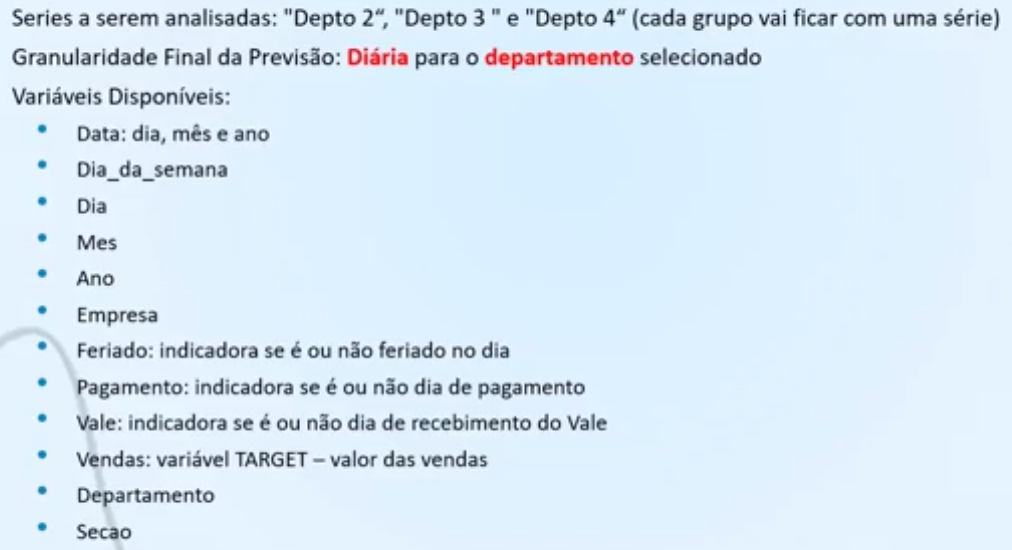

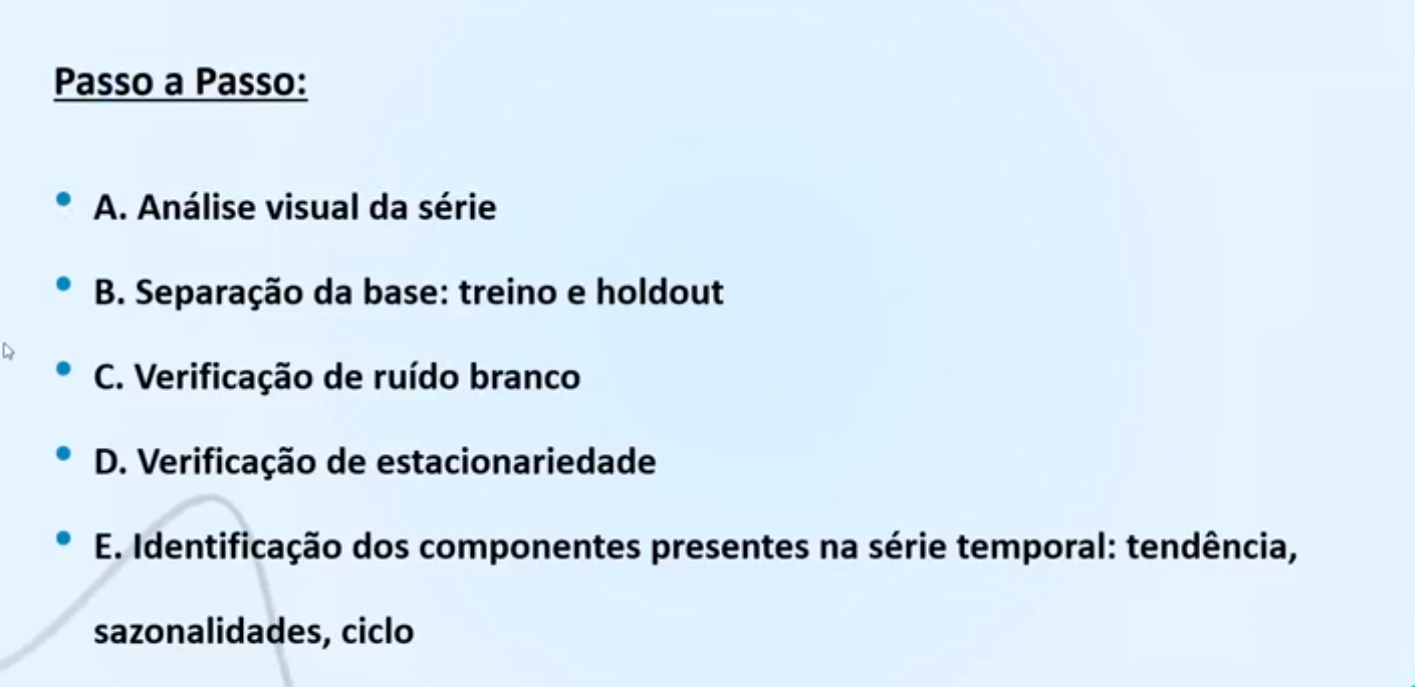

# **BIBLIOTECAS**

In [119]:
# Bibliotecas Básicas e Gráficos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Statsmodels - Ferramentas de Análise e Testes
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf

# Statsmodels - Modelos de Previsão (Passo F)
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

# Métricas de Avaliação (Passo I) - CORRIGIDO
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from math import sqrt

# Configurações de Gráficos
plt.rcParams.update({'figure.figsize': (10, 7), 'figure.dpi': 120})

print('✅ Bibliotecas essenciais carregadas e prontas para o passo a passo!')

✅ Bibliotecas essenciais carregadas e prontas para o passo a passo!


# **1. CARREGAR DADOS**

In [86]:
!pip install gdown # ponte entre Google Drive e Python

In [87]:
import gdown

file_id = "1wJBE7re7rSQ-ZhIyrAXjEA6rt5WGxBQW"

gdown.download(
    f"https://drive.google.com/uc?id={file_id}",
    "Vendas_ASN_Dados_Finais.csv",
    quiet=False
)

Downloading...
From: https://drive.google.com/uc?id=1wJBE7re7rSQ-ZhIyrAXjEA6rt5WGxBQW
To: /content/Vendas_ASN_Dados_Finais.csv
100%|██████████| 21.4M/21.4M [00:00<00:00, 68.5MB/s]


'Vendas_ASN_Dados_Finais.csv'

In [88]:
data = pd.read_csv('Vendas_ASN_Dados_Finais.csv')
data.head(10)

,Data,Data_new,Dia_da_semana,Dia,Mes,Ano,Empresa,Feriado,Pagamento,Vale,Vendas,Departamento,Seção
0,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,316.58,Depto 1,Seção 1
1,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,"94,195.95",Depto 2,Seção 2
2,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,"60,170.14",Depto 2,Seção 3
3,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,"48,120.35",Depto 2,Seção 4
4,01/02/18,1/2/2018,3,2,1,2018,2,0,0,0,"2,622.62",Depto 3,Seção 7
5,01/02/18,1/2/2018,3,2,1,2018,5,0,0,0,"21,277.82",Depto 2,Seção 26
6,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,155.12,Depto 3,Seção 5
7,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,"9,963.10",Depto 3,Seção 6
8,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,"18,400.85",Depto 3,Seção 7
9,01/02/18,1/2/2018,3,2,1,2018,1,0,0,0,"5,114.59",Depto 3,Seção 8


In [89]:
# ver formato que está a data
data['Data_new'].dtype

dtype('O')

In [90]:
data['Data'].dtype

dtype('O')

In [91]:
# Deixar a data no formato de data, e não de object
data['Data'] = pd.to_datetime(pd.DataFrame({
    'day': data['Dia'],
    'month': data['Mes'],
    'year': data['Ano']
}))

In [92]:
data.head(10)

,Data,Data_new,Dia_da_semana,Dia,Mes,Ano,Empresa,Feriado,Pagamento,Vale,Vendas,Departamento,Seção
0,2018-01-02,1/2/2018,3,2,1,2018,1,0,0,0,316.58,Depto 1,Seção 1
1,2018-01-02,1/2/2018,3,2,1,2018,1,0,0,0,"94,195.95",Depto 2,Seção 2
2,2018-01-02,1/2/2018,3,2,1,2018,1,0,0,0,"60,170.14",Depto 2,Seção 3
3,2018-01-02,1/2/2018,3,2,1,2018,1,0,0,0,"48,120.35",Depto 2,Seção 4
4,2018-01-02,1/2/2018,3,2,1,2018,2,0,0,0,"2,622.62",Depto 3,Seção 7
5,2018-01-02,1/2/2018,3,2,1,2018,5,0,0,0,"21,277.82",Depto 2,Seção 26
6,2018-01-02,1/2/2018,3,2,1,2018,1,0,0,0,155.12,Depto 3,Seção 5
7,2018-01-02,1/2/2018,3,2,1,2018,1,0,0,0,"9,963.10",Depto 3,Seção 6
8,2018-01-02,1/2/2018,3,2,1,2018,1,0,0,0,"18,400.85",Depto 3,Seção 7
9,2018-01-02,1/2/2018,3,2,1,2018,1,0,0,0,"5,114.59",Depto 3,Seção 8


In [93]:
data['Data'].dtype

dtype('<M8[ns]')

# **2. TRANSFORMAR DADOS TRANSACIONAIS EM AGREGADOS**

Método de acumulação - soma

Intervalo de tempo - diária

In [94]:
data['Vendas'] = (
    data['Vendas']
    .astype(str)
    .str.replace(',', '', regex=False)
    .astype(float)
)

# QUANTAS VENDAS TEM POR DEPARTAMENTO?

total_departamento = (
    data.groupby('Departamento', as_index=False)['Vendas']
      .sum()
)

# Total geral
total_geral = total_departamento['Vendas'].sum()

# Percentual de participação
total_departamento['Perc'] = (
    total_departamento['Vendas'] / total_geral * 100
)

# Valor em milhões
total_departamento['Vendas_MM'] = (
    total_departamento['Vendas'] / 1_000_000
)

# Formatação
total_departamento['Vendas_MM'] = (
    total_departamento['Vendas_MM']
    .map(lambda x: f'{x:,.2f} MM')
)

total_departamento['Perc'] = (
    total_departamento['Perc']
    .map(lambda x: f'{x:.2f}%')
)

print(total_departamento)

  Departamento        Vendas    Perc    Vendas_MM
0      Depto 1  5.295840e+06   0.09%      5.30 MM
1      Depto 2  3.265787e+09  54.12%  3,265.79 MM
2     Depto 3   2.474437e+08   4.10%    247.44 MM
3      Depto 4  2.460234e+09  40.77%  2,460.23 MM
4      Depto 5  5.052954e+07   0.84%     50.53 MM
5      Depto 6  4.219464e+06   0.07%      4.22 MM
6      Depto 7  9.759944e+05   0.02%      0.98 MM


Para continuar a análise, foi escolhido o departamento 4 por representar 41% das vendas.

In [95]:
# Filtrar apenas o Depto 4
data_depto4 = data[data['Departamento'] == 'Depto 4']

# Verificar se existe alguma venda negativa
tem_negativo = (data_depto4['Vendas'] < 0).any()
print("Existe venda negativa?", tem_negativo)

# Listar todas as linhas com vendas negativas
vendas_negativas = data_depto4[data_depto4['Vendas'] < 0]
print(vendas_negativas)

Existe venda negativa? True
             Data    Data_new  Dia_da_semana  Dia  Mes   Ano  Empresa  \
288456 2020-11-23  11/23/2020              2   23   11  2020       23   

        Feriado  Pagamento  Vale  Vendas Departamento     Seção  
288456        0          0     0   -5.66      Depto 4  Seção 20  


In [96]:
# Substituir as linhas negativas

df_depto = data[data['Departamento'] == 'Depto 4'].copy()

# 2. Identificar dinamicamente os índices de todas as linhas que contêm vendas negativas
indices_com_erro = df_depto[df_depto['Vendas'] < 0].index

if len(indices_com_erro) > 0:
    print(f"Detectadas {len(indices_com_erro)} linhas com vendas negativas.")

    # 3. Iterar de forma puramente dinâmica sobre os índices com erro
    for idx in indices_com_erro:
        # Extrai o mês e o ano DIRETAMENTE da linha que apresentou o erro
        mes_dinamico = df_depto.loc[idx, 'Mes']
        ano_dinamico = df_depto.loc[idx, 'Ano']
        valor_original = df_depto.loc[idx, 'Vendas']

        # Filtra a base para calcular a média apenas das vendas válidas (>= 0)
        # do mesmo mês e ano que foram identificados acima
        filtro_periodo_valido = (
            (df_depto['Mes'] == mes_dinamico) &
            (df_depto['Ano'] == ano_dinamico) &
            (df_depto['Vendas'] >= 0)
        )
        media_periodo = df_depto.loc[filtro_periodo_valido, 'Vendas'].mean()

        # Substitui o valor negativo na linha exata usando o índice
        df_depto.loc[idx, 'Vendas'] = media_periodo
        print(f"   Período identificado: {mes_dinamico:02d}/{ano_dinamico}")
        print(f"   Valor corrigido de {valor_original} para a média de {media_periodo:.2f}\n")
else:
    print("Nenhum valor negativo encontrado. A base está limpa!")

# 4. Validação final automática
restou_negativo = (df_depto['Vendas'] < 0).any()
print("Ainda existem valores negativos na série?", restou_negativo)

Detectadas 1 linhas com vendas negativas.
   Período identificado: 11/2020
   Valor corrigido de -5.66 para a média de 34666.02

Ainda existem valores negativos na série? False


In [97]:
df_depto

,Data,Data_new,Dia_da_semana,Dia,Mes,Ano,Empresa,Feriado,Pagamento,Vale,Vendas,Departamento,Seção
20,2018-01-02,1/2/2018,3,2,1,2018,1,0,0,0,73241.03,Depto 4,Seção 18
21,2018-01-02,1/2/2018,3,2,1,2018,1,0,0,0,71675.73,Depto 4,Seção 19
22,2018-01-02,1/2/2018,3,2,1,2018,1,0,0,0,120764.96,Depto 4,Seção 20
23,2018-01-02,1/2/2018,3,2,1,2018,1,0,0,0,90562.58,Depto 4,Seção 21
24,2018-01-02,1/2/2018,3,2,1,2018,1,0,0,0,4934.41,Depto 4,Seção 22
...,...,...,...,...,...,...,...,...,...,...,...,...,...
306996,2021-02-28,2/28/2021,1,28,2,2021,21,0,0,0,36454.57,Depto 4,Seção 19
306997,2021-02-28,2/28/2021,1,28,2,2021,21,0,0,0,46405.58,Depto 4,Seção 20
306998,2021-02-28,2/28/2021,1,28,2,2021,21,0,0,0,55328.16,Depto 4,Seção 21
307000,2021-02-28,2/28/2021,1,28,2,2021,21,0,0,0,77382.53,Depto 4,Seção 18


In [98]:
vendas_dia = (
    data_depto4.groupby(['Data'])['Vendas']
      .sum()
      .reset_index()
)

print(vendas_dia)


           Data      Vendas
0    2018-01-02  1812134.19
1    2018-01-03  1622115.60
2    2018-01-04  1486888.42
3    2018-01-05  2015469.36
4    2018-01-06  2678387.64
...         ...         ...
1143 2021-02-24  2025751.85
1144 2021-02-25  2216224.47
1145 2021-02-26  3098829.40
1146 2021-02-27  4592539.97
1147 2021-02-28  2157356.38

[1148 rows x 2 columns]


In [99]:
# ANÁLISE DA VARIÁVEL VENDA:

vendas_dia['Vendas'].describe()

,Vendas
count,1.148000e+03
mean,2.143061e+06
std,7.398696e+05
min,5.802061e+05
25%,1.632986e+06
50%,1.954044e+06
75%,2.459384e+06
max,5.363986e+06


In [100]:
vendas_dia['Ano'] = vendas_dia['Data'].dt.year

vendas_dia.head(10)

,Data,Vendas,Ano
0,2018-01-02,1812134.19,2018
1,2018-01-03,1622115.60,2018
2,2018-01-04,1486888.42,2018
3,2018-01-05,2015469.36,2018
4,2018-01-06,2678387.64,2018
5,2018-01-07,1120660.99,2018
6,2018-01-08,1600882.79,2018
7,2018-01-09,1963629.68,2018
8,2018-01-10,1667902.81,2018
9,2018-01-11,1457775.73,2018


In [101]:
vendas_dia_temp = vendas_dia.set_index('Data')
data_inicio = vendas_dia_temp.index.min()
data_fim = vendas_dia_temp.index.max()
calendario_completo = pd.date_range(start=data_inicio, end=data_fim, freq='D')

vendas_reindexado = vendas_dia_temp.reindex(calendario_completo)
datas_faltantes = vendas_reindexado[vendas_reindexado['Vendas'].isna()].index

print(f"Havia um total de {len(datas_faltantes)} datas faltantes na série original.")
if len(datas_faltantes) > 0:
    print("\n--- Lista das datas faltantes identificadas ---")
    for data_faltante in datas_faltantes:
        print(data_faltante.date())
else:
    print("\nNenhuma data faltante encontrada!")

# Criar a nova série substituindo os NaNs por 0.000001 de forma explícita
vendas_dia_completo = vendas_reindexado.copy()
vendas_dia_completo['Vendas'] = vendas_dia_completo['Vendas'].fillna(0.000001)

# Renomear o índice para 'Data' para manter o padrão limpo
vendas_dia_completo.index.name = 'Data'

print("\n--- Verificação após a substituição ---")
print(f"Quantidade de NaNs restantes: {vendas_dia_completo['Vendas'].isna().sum()}")
print(f"Quantidade de dias com valor 0.000001: {(vendas_dia_completo['Vendas'] == 0.000001).sum()}")
print(f"Havia um total de {total_faltantes} datas faltantes (buracos no calendário) na série original.")

Havia um total de 6 datas faltantes na série original.

--- Lista das datas faltantes identificadas ---
2018-12-25
2019-01-01
2019-12-25
2020-01-01
2020-12-25
2021-01-01

--- Verificação após a substituição ---
Quantidade de NaNs restantes: 0
Quantidade de dias com valor 0.000001: 6
Havia um total de 6 datas faltantes (buracos no calendário) na série original.


In [102]:
vendas_dia_completo

,Vendas,Ano
Data,,
2018-01-02,1812134.19,2018.0
2018-01-03,1622115.60,2018.0
2018-01-04,1486888.42,2018.0
2018-01-05,2015469.36,2018.0
2018-01-06,2678387.64,2018.0
...,...,...
2021-02-24,2025751.85,2021.0
2021-02-25,2216224.47,2021.0
2021-02-26,3098829.40,2021.0


In [104]:
vendas_dia_completo = vendas_dia_completo.reset_index()

In [105]:
vendas_dia_completo['Data'].dtype

dtype('<M8[ns]')

In [106]:
vendas_dia_completo['Data'] = pd.to_datetime(vendas_dia_completo['Data'])

# **3. ANÁLISE VISUAL E IDENTIFICAÇÃO DE COMPONENTES**

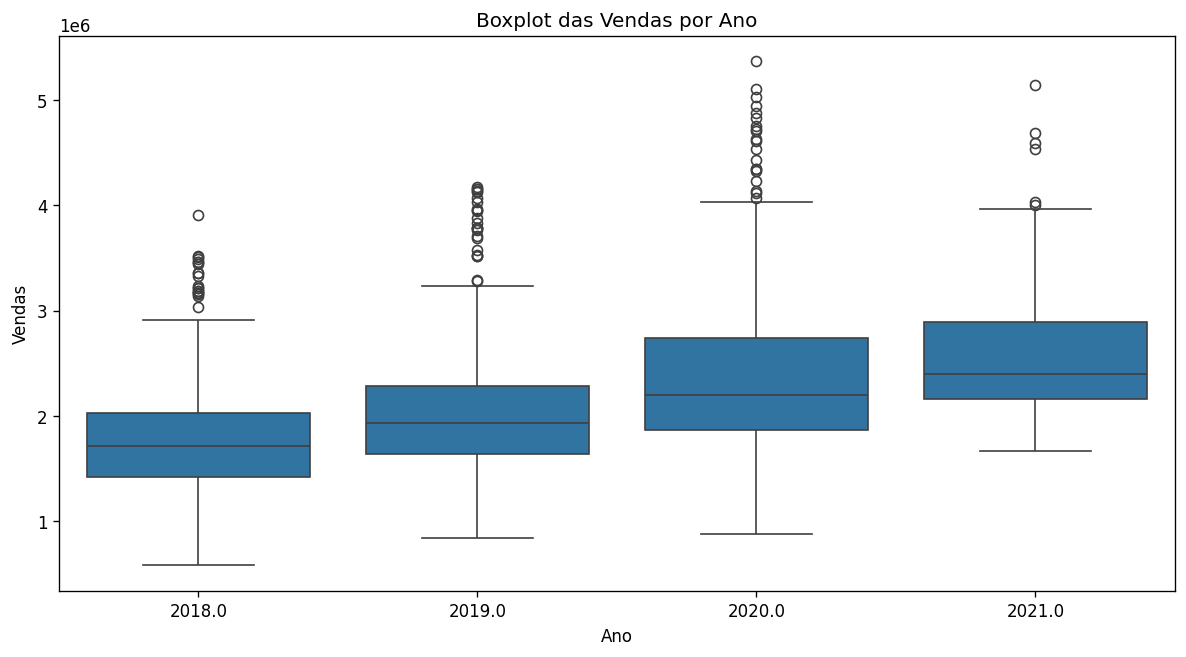

In [107]:
# BOXPLOT AO LONGO DOS ANOS:

fig, ax = plt.subplots(figsize=(12,6))

sns.boxplot(
    data=vendas_dia_completo,
    x='Ano',
    y='Vendas',
    ax=ax
)

plt.title('Boxplot das Vendas por Ano')
plt.show()

In [108]:
vendas_dia_completo.groupby('Ano')['Vendas'].describe()

,count,mean,std,min,25%,50%,75%,max
Ano,,,,,,,,
2018.0,363.0,1.827837e+06,579069.807873,580206.06,1.415357e+06,1710038.510,2.025495e+06,3906138.25
2019.0,363.0,2.089768e+06,640858.788881,836348.22,1.637741e+06,1932448.020,2.283950e+06,4168269.68
2020.0,364.0,2.427573e+06,814747.069522,878158.71,1.863710e+06,2201581.005,2.734793e+06,5363986.16
2021.0,58.0,2.663906e+06,778574.868966,1667474.63,2.161169e+06,2399303.330,2.891777e+06,5141515.66


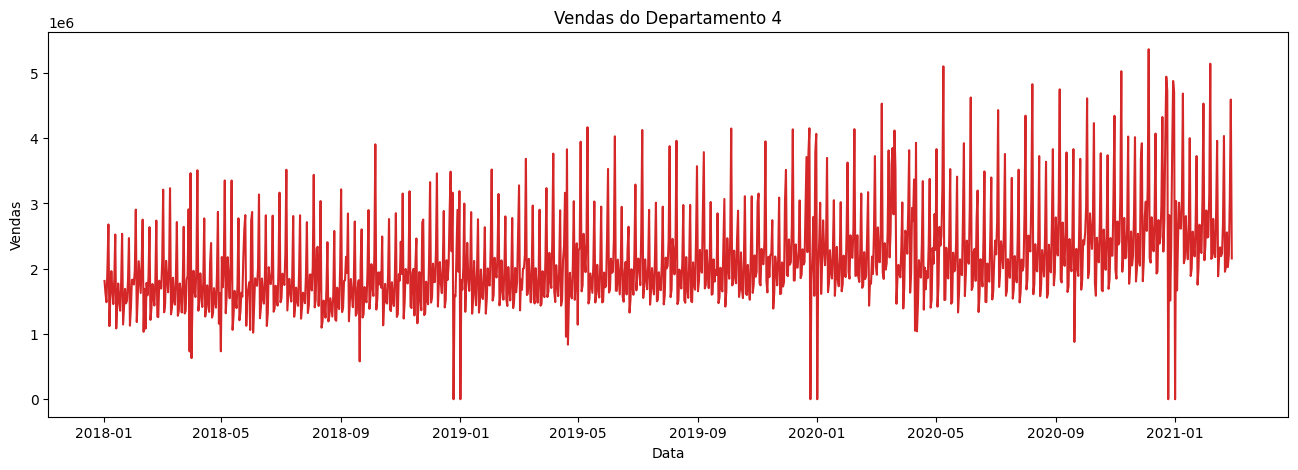

In [109]:
# Visualizando a série temporal

def plot_df(vendas_dia_completo, x, y, title="", xlabel='Data', ylabel='Vendas', dpi=100):
    plt.figure(figsize=(16,5), dpi=dpi)
    plt.plot(x, y, color='tab:red')
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.show()

plot_df(
    vendas_dia_completo=vendas_dia_completo,
    x=vendas_dia_completo['Data'],
    y=vendas_dia_completo['Vendas'],
    title='Vendas do Departamento 4'
)

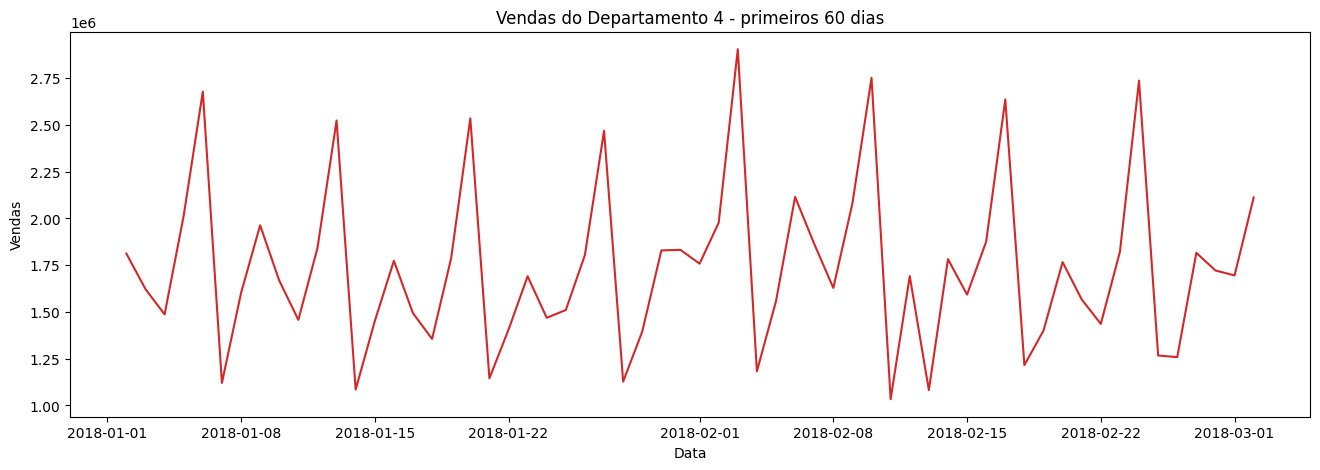

In [110]:
# Visualizando a série temporal em um intervalo de tempo menor

vendas_dia_completo = vendas_dia_completo.sort_values('Data')

trecho = vendas_dia_completo.iloc[:60]

plot_df(
    vendas_dia_completo=trecho,
    x=trecho['Data'],
    y=trecho['Vendas'],
    title='Vendas do Departamento 4 - primeiros 60 dias'
)

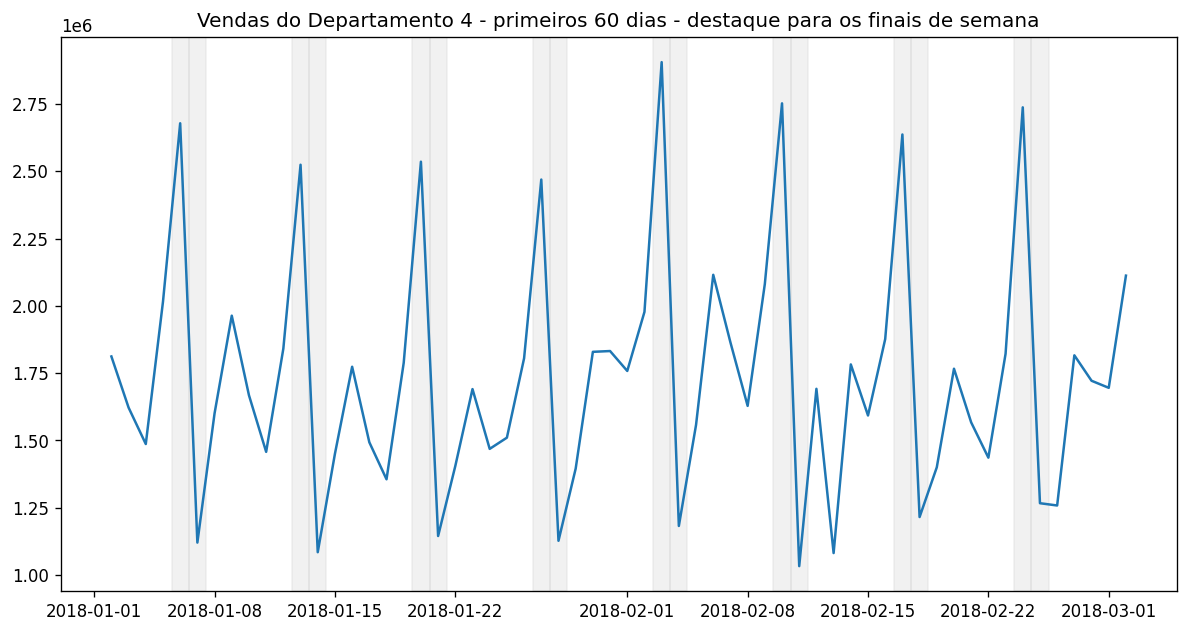

In [111]:
fig, ax = plt.subplots(figsize=(12,6))

ax.plot(trecho['Data'], trecho['Vendas'])

# destacar finais de semana
for data in trecho.loc[trecho['Data'].dt.dayofweek >= 5, 'Data']:
    ax.axvspan(
        data - pd.Timedelta(hours=12),
        data + pd.Timedelta(hours=12),
        color='lightgray',
        alpha=0.3
    )
ax.set_title('Vendas do Departamento 4 - primeiros 60 dias - destaque para os finais de semana')
plt.show()

A série temporal apresenta comportamento predominantemente estacionário, sem tendência definida no período analisado. Observam-se oscilações diárias em torno de um nível médio aproximadamente constante, acompanhadas de elevada variabilidade e indícios de sazonalidade de curta duração, possivelmente semanal.

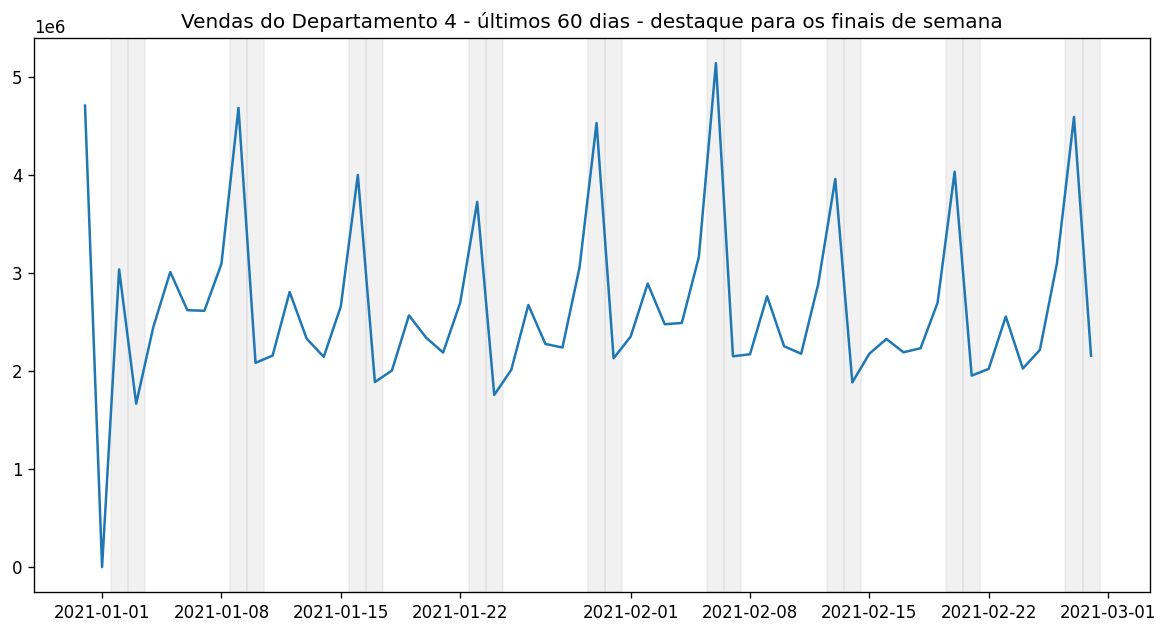

In [112]:
trecho_fim = vendas_dia_completo.tail(60)

fig, ax = plt.subplots(figsize=(12,6))

ax.plot(trecho_fim['Data'], trecho_fim['Vendas'])

for data in trecho_fim.loc[trecho_fim['Data'].dt.dayofweek >= 5, 'Data']:
    ax.axvspan(
        data - pd.Timedelta(hours=12),
        data + pd.Timedelta(hours=12),
        color='lightgray',
        alpha=0.3
    )

ax.set_title('Vendas do Departamento 4 - últimos 60 dias - destaque para os finais de semana')
plt.show()

DECOMPOSIÇÃO MULTIPLICATIVA DA SÉRIE:

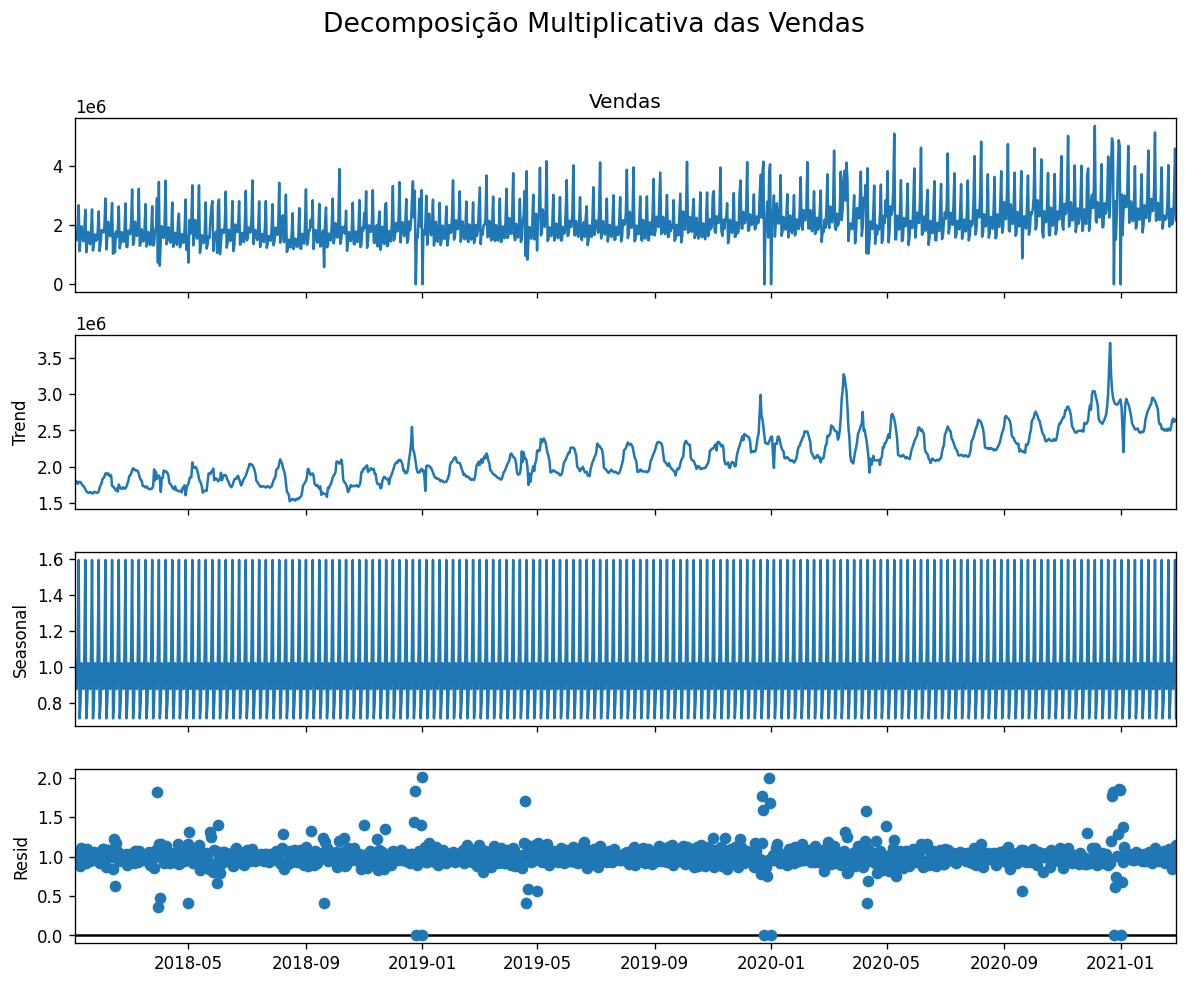

In [113]:
# PADRÃO SEMANAL
from statsmodels.tsa.seasonal import seasonal_decompose

# Definimos a Data como índice temporariamente e extraímos apenas a coluna 'Vendas'
serie_temporal = vendas_dia_completo.set_index('Data')['Vendas']

# Executar a decomposição multiplicativa na série ajustada
result_mul = seasonal_decompose(
    serie_temporal,
    model='multiplicative',
    period=7,  # sazonalidade semanal
    extrapolate_trend='freq'
)

# Configurar e plotar os gráficos dos componentes (Tendência, Sazonalidade e Ruído)
plt.rcParams.update({'figure.figsize': (10, 8)})

result_mul.plot()

# Adiciona o título global corretamente
plt.suptitle(
    'Decomposição Multiplicativa das Vendas',
    fontsize=16,
    y=1.02 # Ajusta a altura para não sobrepor o gráfico superior
)

plt.tight_layout()
plt.show()

A decomposição multiplicativa confirma que a série temporal de vendas do Departamento 4 possui uma tendência de alta consistente de longo prazo (saindo de patamares próximos a 1,7 milhão em 2018 e superando 2,5 milhões a partir de 2020) e uma sazonalidade semanal altamente marcante, com fatores multiplicativos que variam de 0,7 a 1,6 vezes o valor da tendência conforme o dia da semana. O gráfico dos resíduos demonstra estabilidade geral ao redor do valor 1,0, o que valida a escolha do modelo multiplicativo, evidenciando apenas variações extremas pontuais perto de zero nas viradas de ano, causadas pelo preenchimento dos dias em que não houve faturamento registrado.

Em resumo, foi identificado por meio do Boxplot e da Decomposição:

*   Tendência: Sim, de alta ao longo dos anos.
*   Sazonalidade: Sim, fortemente semanal (período = 7).
*   Ciclo: Não há ciclos de longo prazo visíveis (como ciclos econômicos de vários anos).

# **4. SEPARAÇÃO DA SÉRIE ENTRE TREINO E TESTE**

In [114]:
df_temporario = vendas_dia_completo.set_index('Data')

# Divisão conforme as regras do exercício da DSA
treino = df_temporario.loc[:'2020-12-31']
holdout = df_temporario.loc['2021-01-01':'2021-02-28']

print(f"Base de Treinamento: {len(treino)} dias (até {treino.index.max().date()})")
print(f"Base de Holdout: {len(holdout)} dias (de {holdout.index.min().date()} até {holdout.index.max().date()})")

Base de Treinamento: 1095 dias (até 2020-12-31)
Base de Holdout: 59 dias (de 2021-01-01 até 2021-02-28)


# **5. VERIFICAÇÃO DE RUÍDO BRANCO (NA BASE DE TREINO)**

In [116]:
# Testando se a série de treino é aleatória (Ruído Branco)
resultado_lb = acorr_ljungbox(treino['Vendas'], lags=[7], return_df=True)

print("--- TESTE DE LJUNG-BOX ---")
print(resultado_lb)

p_valor_lb = resultado_lb['lb_pvalue'].values[0]
if p_valor_lb < 0.05:
    print(f"\np-valor = {p_valor_lb:.5f} (< 0.05). Rejeitamos a hipótese nula!")
    print("A série NÃO é ruído branco. Podemos seguir com a modelagem. 🚀")
else:
    print("\nA série é ruído branco. Não há padrões previsíveis.")

--- TESTE DE LJUNG-BOX ---
      lb_stat      lb_pvalue
7  790.683389  1.900583e-166

p-valor = 0.00000 (< 0.05). Rejeitamos a hipótese nula!
A série NÃO é ruído branco. Podemos seguir com a modelagem. 🚀


# **6. VERIFICAÇÃO DE ESTACIONARIEDADE (Na Base de Treino)**

In [118]:
resultado_adf = adfuller(treino['Vendas'])

print("--- PASSO D: TESTE DE ESTACIONARIEDADE (ADF) ---")
print(f"Estatística ADF: {resultado_adf[0]:.4f}")
print(f"p-valor: {resultado_adf[1]:.5f}")
print("\nValores Críticos de Controle:")
for chave, valor in resultado_adf[4].items():
    print(f"   {chave}: {valor:.4f}")

# Validação do p-valor
if resultado_adf[1] < 0.05:
    print("\nAnálise: p-valor < 0.05. A série já é ESTACIONÁRIA! (d = 0) 🎯")
else:
    print("\nAnálise: p-valor >= 0.05. A série NÃO é estacionária. Precisaremos aplicar diferenciação (d >= 1). ⚠️")

--- PASSO D: TESTE DE ESTACIONARIEDADE (ADF) ---
Estatística ADF: -1.5772
p-valor: 0.49501

Valores Críticos de Controle:
   1%: -3.4365
   5%: -2.8642
   10%: -2.5682

Análise: p-valor >= 0.05. A série NÃO é estacionária. Precisaremos aplicar diferenciação (d >= 1). ⚠️


# **7. VERIFICAÇÃO DE SAZONALIDADE**

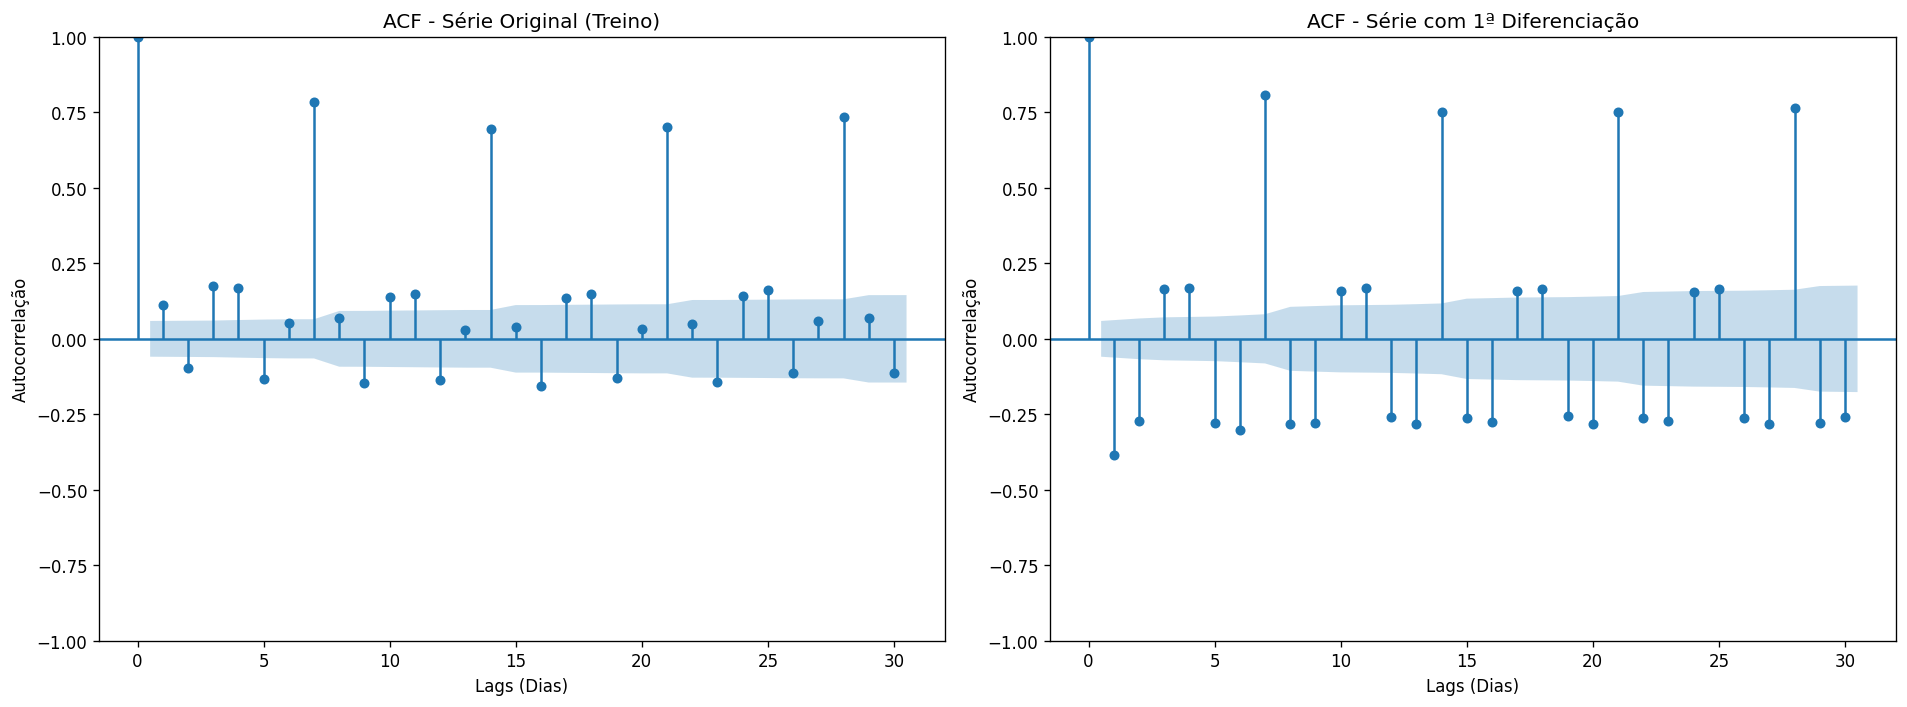

In [120]:
# Verificando autocorrelação
# Usando função ACF

# Criando a estrutura de subplots (lado a lado)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 1. ACF da Série Original (Treino)
# Mostra o efeito da tendência + sazonalidade
plot_acf(treino['Vendas'], lags=30, ax=ax1, title="ACF - Série Original (Treino)")
ax1.set_xlabel("Lags (Dias)")
ax1.set_ylabel("Autocorrelação")

# 2. ACF da Série Diferenciada (Removendo a tendência)
# Mostra puramente a sazonalidade isolada
plot_acf(treino['Vendas'].diff().dropna(), lags=30, ax=ax2, title="ACF - Série com 1ª Diferenciação")
ax2.set_xlabel("Lags (Dias)")
ax2.set_ylabel("Autocorrelação")

plt.tight_layout()
plt.show()

Os gráficos de autocorrelação (ACF) confirmam e provam matematicamente a forte presença de sazonalidade semanal na série de vendas do Departamento 4. Enquanto o primeiro gráfico exibe barras persistentemente altas devido à tendência de longo prazo já identificada, o segundo gráfico — gerado após a aplicação da primeira diferenciação para estabilizar a média — isola o comportamento sazonal de forma cristalina, destacando picos intensos e significativos fora da área sombreada de controle exatamente nos lags 7, 14, 21 e 28. Essa repetição exata a cada sete dias valida estatisticamente que o volume de vendas do dia atual é fortemente dependente e correlacionado com o que aconteceu no mesmo dia da semana anterior, justificando tecnicamente o uso de modelagens sazonais (como Holt-Winters e SARIMA com período igual a 7) para o pipeline preditivo.

# **8. MODELOS**

## **8.1 Família Alisamento Exponencial: Holt-Winters Multiplicativo:**



**1. Simples: Simple Exponential Smoothing (SES)**

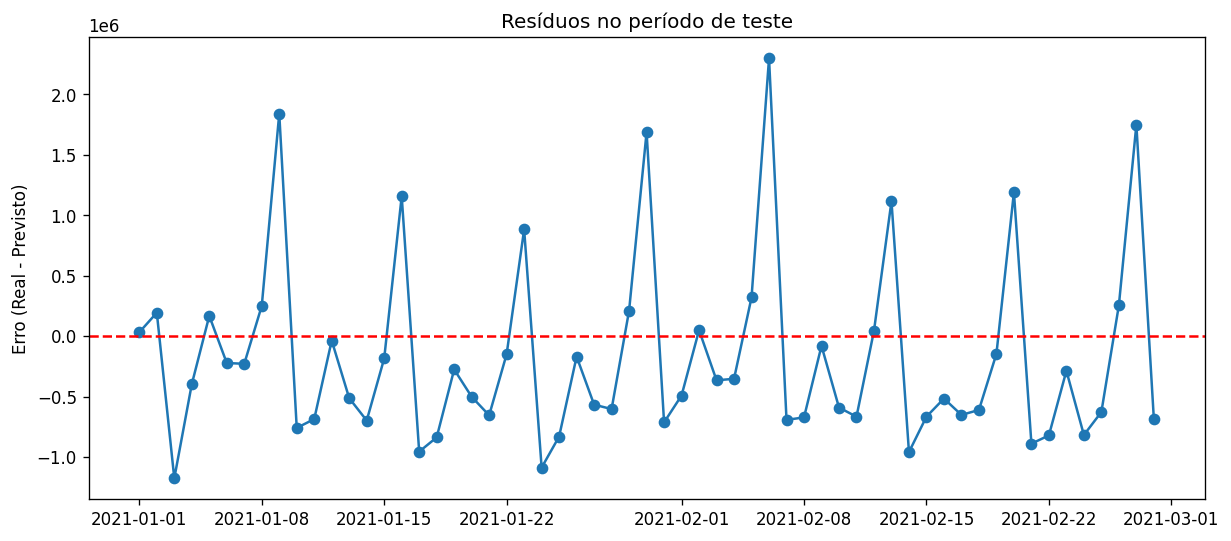

In [ ]:
erro = teste['Vendas'].values - fcast1.values

plt.figure(figsize=(12,5))
plt.plot(teste['Data_BR'], erro, marker='o')
plt.axhline(0, color='red', linestyle='--')

plt.title('Resíduos no período de teste')
plt.ylabel('Erro (Real - Previsto)')
plt.show()

In [ ]:
# Resíduos do modelo SES
residuos_ses = fit1.resid

# Teste de Ljung-Box até 20 defasagens
ljung_ses = acorr_ljungbox(residuos_ses, lags=[7, 14, 21], return_df=True)

print("Teste de Ljung-Box - SES")
for lag, row in ljung_ses.iterrows():
    pvalor = row['lb_pvalue']
    if pvalor > 0.05:
        print(f"Lag {lag}: p-valor={pvalor:.4f} → NÃO há autocorrelação (resíduos ~ ruído branco)")
    else:
        print(f"Lag {lag}: p-valor={pvalor:.4f} → Há autocorrelação significativa (modelo não capturou tudo)")

Teste de Ljung-Box - SES
Lag 7: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 14: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 21: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)


**2. HOLT SEM TENDÊNCIA AMORTECIDA**

MAE Holt: 829,639
RMSE Holt: 935,464
MAPE Holt: 34.47%


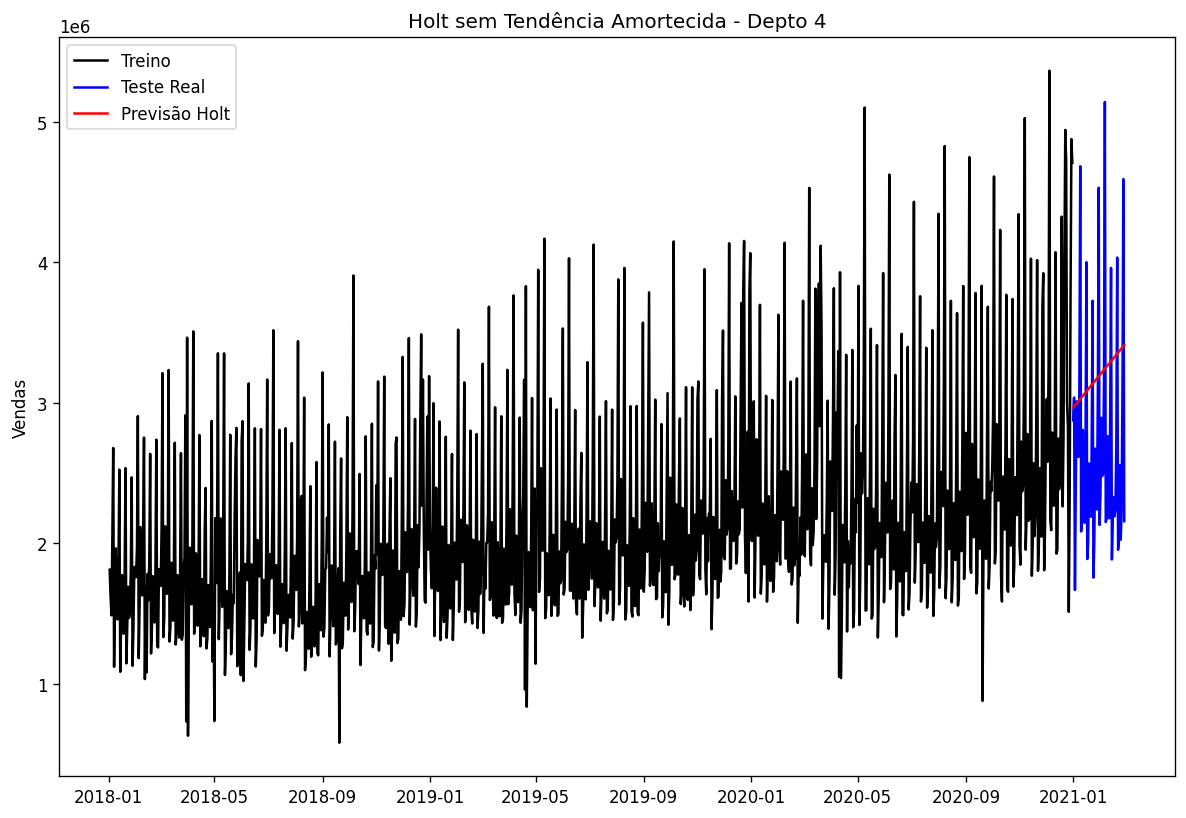

In [ ]:
# Ajustar modelo Holt (sem tendência amortecida)
fit1_ht = Holt(treino['Vendas'], damped_trend=False, initialization_method="estimated").fit()

# Previsão para o tamanho do teste
fcast1_ht = fit1_ht.forecast(len(teste))
fcast1_ht = fcast1_ht.rename("Previsão Holt")

# Comparar com valores reais
resultado_ht = pd.DataFrame({
    'Data': teste['Data_BR'],
    'Real': teste['Vendas'],
    'Previsto': fcast1_ht
})

# Métricas de erro
mae_ht = mean_absolute_error(resultado_ht['Real'], resultado_ht['Previsto'])
rmse_ht = np.sqrt(mean_squared_error(resultado_ht['Real'], resultado_ht['Previsto']))
mape_ht = mean_absolute_percentage_error(resultado_ht['Real'], resultado_ht['Previsto'])

print(f"MAE Holt: {mae_ht:,.0f}")
print(f"RMSE Holt: {rmse_ht:,.0f}")
print(f"MAPE Holt: {mape_ht:.2%}")

# Plotando
plt.figure(figsize=(12,8))
plt.plot(treino['Data_BR'], treino['Vendas'], color='black', label='Treino')
plt.plot(teste['Data_BR'], teste['Vendas'], color='blue', label='Teste Real')
plt.plot(teste['Data_BR'], fcast1_ht, color='red', label='Previsão Holt')
plt.title('Holt sem Tendência Amortecida - Depto 4')
plt.ylabel('Vendas')
plt.legend()
plt.show()

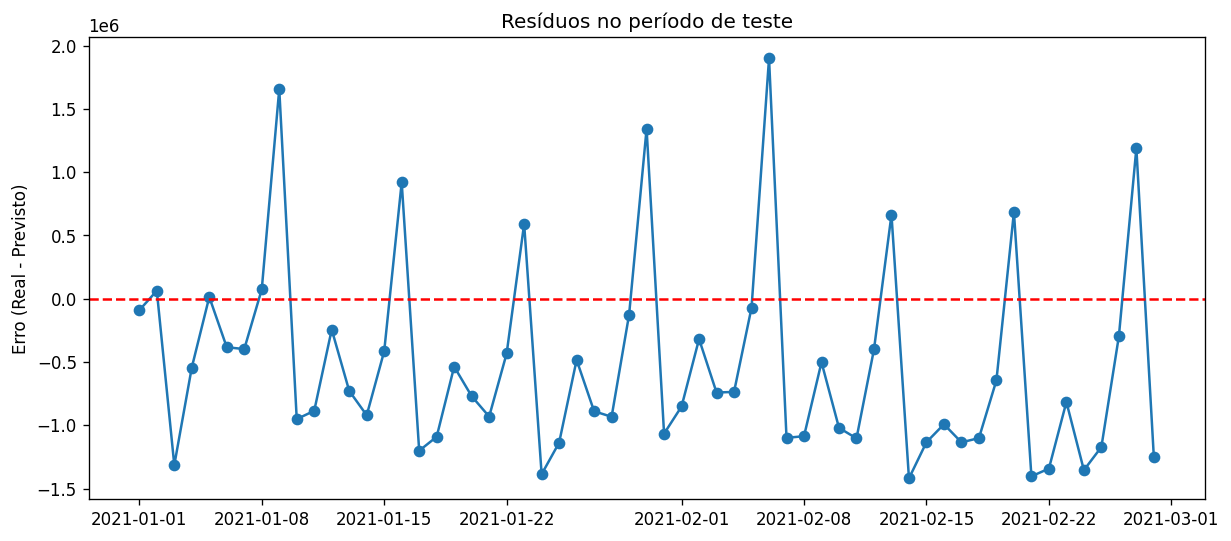

In [ ]:
erro = teste['Vendas'].values - fcast1_ht.values

plt.figure(figsize=(12,5))
plt.plot(teste['Data_BR'], erro, marker='o')
plt.axhline(0, color='red', linestyle='--')

plt.title('Resíduos no período de teste')
plt.ylabel('Erro (Real - Previsto)')
plt.show()

In [ ]:
# Resíduos do modelo Holt sem Tendência Amortecida
residuos_holt = fit1_ht.resid

# Teste de Ljung-Box até 20 defasagens
ljung_holt = acorr_ljungbox(residuos_holt, lags=[7, 14, 21], return_df=True)

print("Teste de Ljung-Box - Holt sem Tendência Amortecida")
for lag, row in ljung_holt.iterrows():
    pvalor = row['lb_pvalue']
    if pvalor > 0.05:
        print(f"Lag {lag}: p-valor={pvalor:.4f} → NÃO há autocorrelação (resíduos ~ ruído branco)")
    else:
        print(f"Lag {lag}: p-valor={pvalor:.4f} → Há autocorrelação significativa (modelo não capturou tudo)")

Teste de Ljung-Box - Holt sem Tendência Amortecida
Lag 7: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 14: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 21: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)


**3. HOLT COM TENDÊNCIA AMORTECIDA (Damped Trend)**

MAE Holt Amortecido: 739,793
RMSE Holt Amortecido: 858,555
MAPE Holt Amortecido: 30.10%


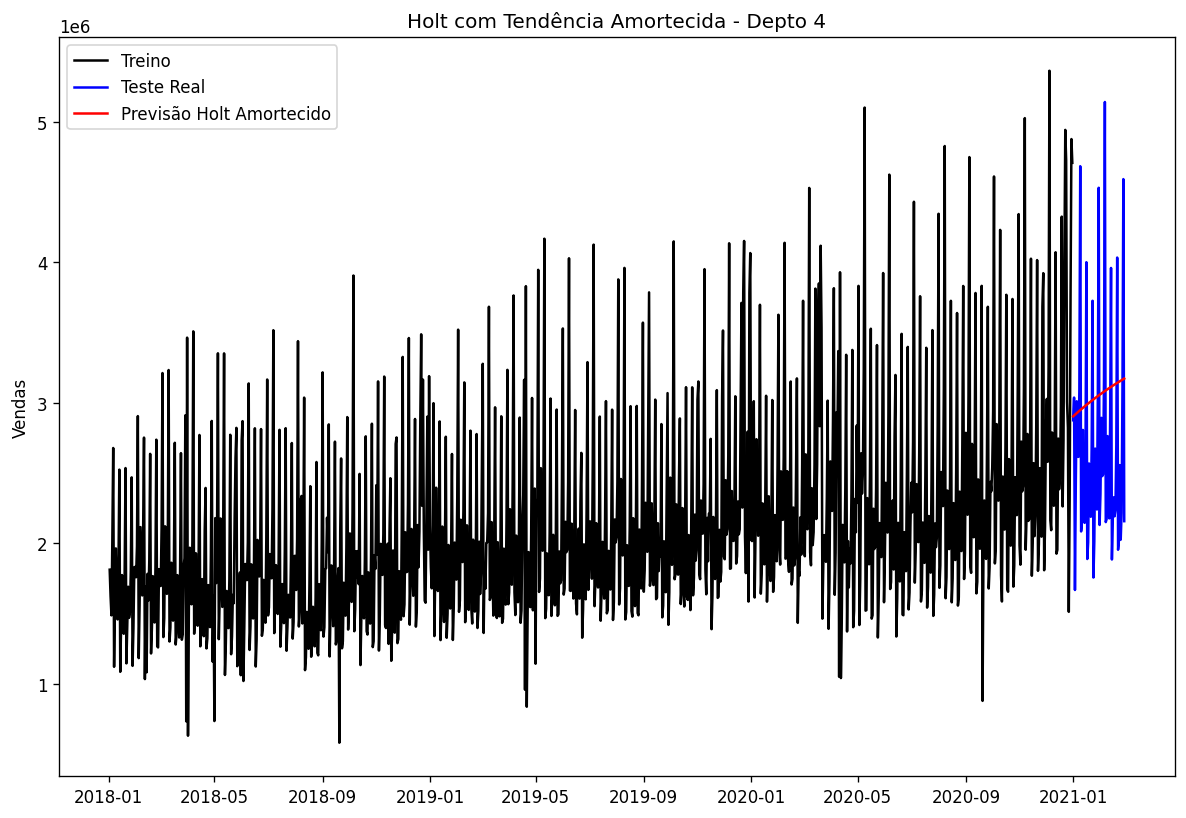

In [ ]:
# Ajustar modelo Holt com tendência amortecida
fit2_ht = Holt(treino['Vendas'], damped_trend=True, initialization_method="estimated").fit()

# Previsão para o tamanho do teste
fcast2_ht = fit2_ht.forecast(len(teste))
fcast2_ht = fcast2_ht.rename("Previsão Holt Amortecido")

# Comparar com valores reais
resultado_ht2 = pd.DataFrame({
    'Data': teste['Data_BR'],
    'Real': teste['Vendas'],
    'Previsto': fcast2_ht
})

# Métricas de erro
mae_ht2 = mean_absolute_error(resultado_ht2['Real'], resultado_ht2['Previsto'])
rmse_ht2 = np.sqrt(mean_squared_error(resultado_ht2['Real'], resultado_ht2['Previsto']))
mape_ht2 = mean_absolute_percentage_error(resultado_ht2['Real'], resultado_ht2['Previsto'])

print(f"MAE Holt Amortecido: {mae_ht2:,.0f}")
print(f"RMSE Holt Amortecido: {rmse_ht2:,.0f}")
print(f"MAPE Holt Amortecido: {mape_ht2:.2%}")

# Plotando
plt.figure(figsize=(12,8))
plt.plot(treino['Data_BR'], treino['Vendas'], color='black', label='Treino')
plt.plot(teste['Data_BR'], teste['Vendas'], color='blue', label='Teste Real')
plt.plot(teste['Data_BR'], fcast2_ht, color='red', label='Previsão Holt Amortecido')
plt.title('Holt com Tendência Amortecida - Depto 4')
plt.ylabel('Vendas')
plt.legend()
plt.show()

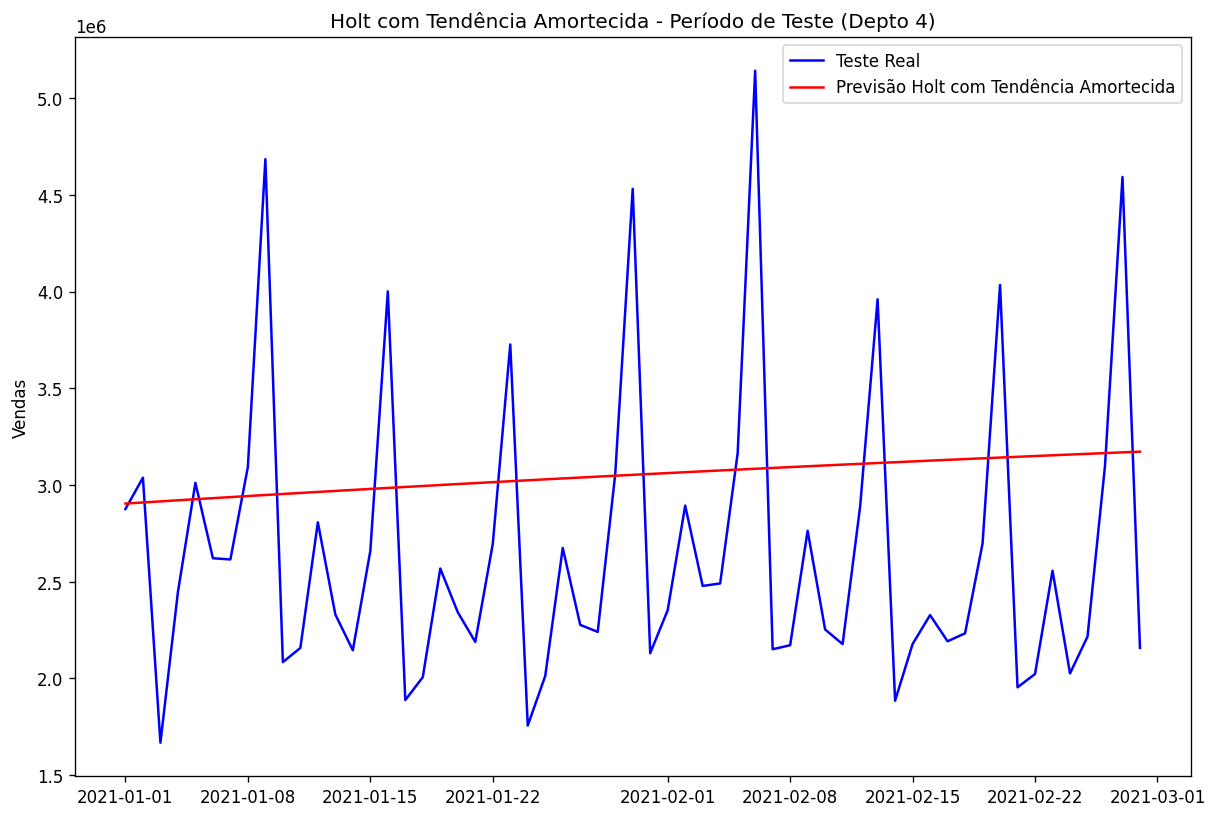

In [ ]:
# Gerar previsão para o período de teste
fcast_ht = fit2_ht.forecast(len(teste))

# Plotar apenas o período de teste
plt.figure(figsize=(12,8))
plt.plot(teste['Data_BR'], teste['Vendas'], color='blue', label='Teste Real')
plt.plot(teste['Data_BR'], fcast_ht, color='red', label='Previsão Holt com Tendência Amortecida')
plt.title('Holt com Tendência Amortecida - Período de Teste (Depto 4)')
plt.ylabel('Vendas')
plt.legend()
plt.show()

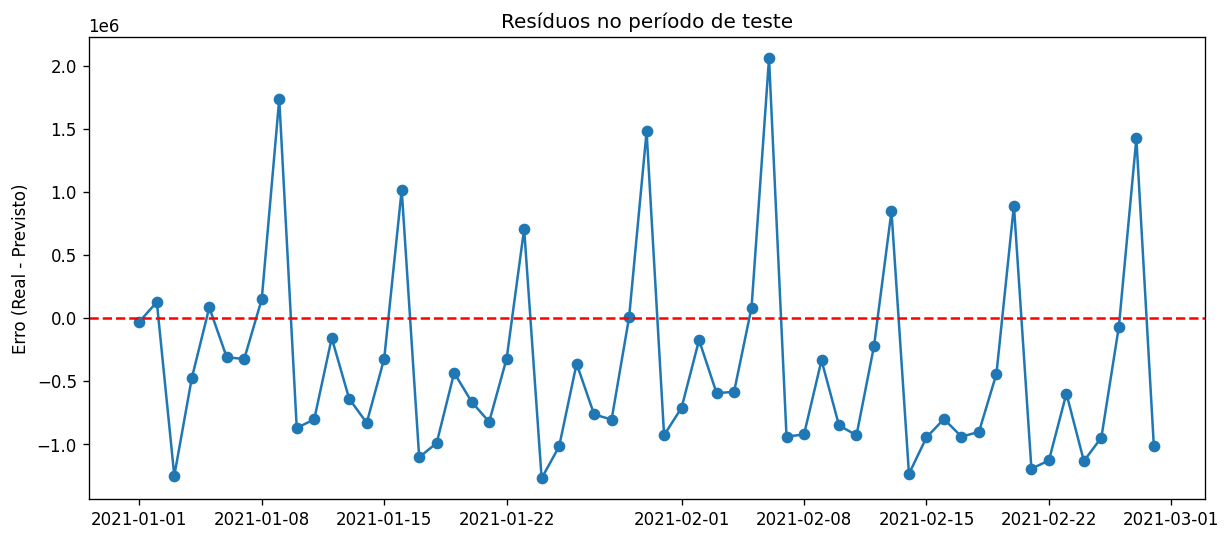

In [ ]:
erro = teste['Vendas'].values - fcast2_ht.values

plt.figure(figsize=(12,5))
plt.plot(teste['Data_BR'], erro, marker='o')
plt.axhline(0, color='red', linestyle='--')

plt.title('Resíduos no período de teste')
plt.ylabel('Erro (Real - Previsto)')
plt.show()

In [ ]:
# Resíduos do modelo Holt sem Tendência Amortecida
residuos_holt2 = fit2_ht.resid

# Teste de Ljung-Box até 20 defasagens
ljung_holt2 = acorr_ljungbox(residuos_holt2, lags=[7, 14, 21], return_df=True)

print("Teste de Ljung-Box - Holt com Tendência Amortecida")
for lag, row in ljung_holt2.iterrows():
    pvalor = row['lb_pvalue']
    if pvalor > 0.05:
        print(f"Lag {lag}: p-valor={pvalor:.4f} → NÃO há autocorrelação (resíduos ~ ruído branco)")
    else:
        print(f"Lag {lag}: p-valor={pvalor:.4f} → Há autocorrelação significativa (modelo não capturou tudo)")

Teste de Ljung-Box - Holt com Tendência Amortecida
Lag 7: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 14: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 21: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)


In [ ]:
# Ajustar modelos
fit1 = SimpleExpSmoothing(treino['Vendas'], initialization_method="estimated").fit()
fit2 = Holt(treino['Vendas'], initialization_method="estimated").fit()
fit3 = Holt(treino['Vendas'], exponential=True, initialization_method="estimated").fit()
fit4 = Holt(treino['Vendas'], damped_trend=True, initialization_method="estimated").fit(damping_trend=0.98)
fit5 = Holt(treino['Vendas'], exponential=True, damped_trend=True, initialization_method="estimated").fit()

# Previsões para o teste
models = {
    "SES": fit1.forecast(len(teste)),
    "Holt's": fit2.forecast(len(teste)),
    "Exponential": fit3.forecast(len(teste)),
    "Additive": fit4.forecast(len(teste)),
    "Multiplicative": fit5.forecast(len(teste))
}

# Calcular métricas
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

results = []
for name, forecast in models.items():
    mae = mean_absolute_error(teste['Vendas'], forecast)
    rmse = np.sqrt(mean_squared_error(teste['Vendas'], forecast))
    mape = mean_absolute_percentage_error(teste['Vendas'], forecast)
    results.append([name, mae, rmse, mape])

# Tabela final
df_results = pd.DataFrame(results, columns=["Modelo", "MAE", "RMSE", "MAPE"])
print(df_results)

           Modelo            MAE           RMSE      MAPE
0             SES  631475.299127  785520.561513  0.244798
1          Holt's  829638.823654  935464.112327  0.344705
2     Exponential  869822.711763  974500.239705  0.363957
3        Additive  692266.847307  821994.055977  0.276835
4  Multiplicative  752099.056835  868427.841182  0.307082


Apesar de a série apresentar visualmente um leve crescimento, o parâmetro de tendência estimado pelo modelo de Holt foi praticamente nulo (β ≈ 0), indicando que a inclusão de uma componente de tendência não trouxe ganho significativo ao ajuste. O modelo Holt apresentou o menor valor de SSE, porém seu comportamento é bastante semelhante ao da Suavização Exponencial Simples.


*  O SES (Simple Exponential Smoothing) foi o mais eficaz, com menor MAPE e erros absolutos mais baixos;

*  Os modelos Holt (simples, exponencial e amortecidos) não superaram o SES, sugerindo que a série tem padrão estacionário com sazonalidade curta, e não uma tendência forte.

*  Isso confirma o que foi observado na decomposição: oscilações semanais e crescimento moderado, mas sem tendência linear clara.

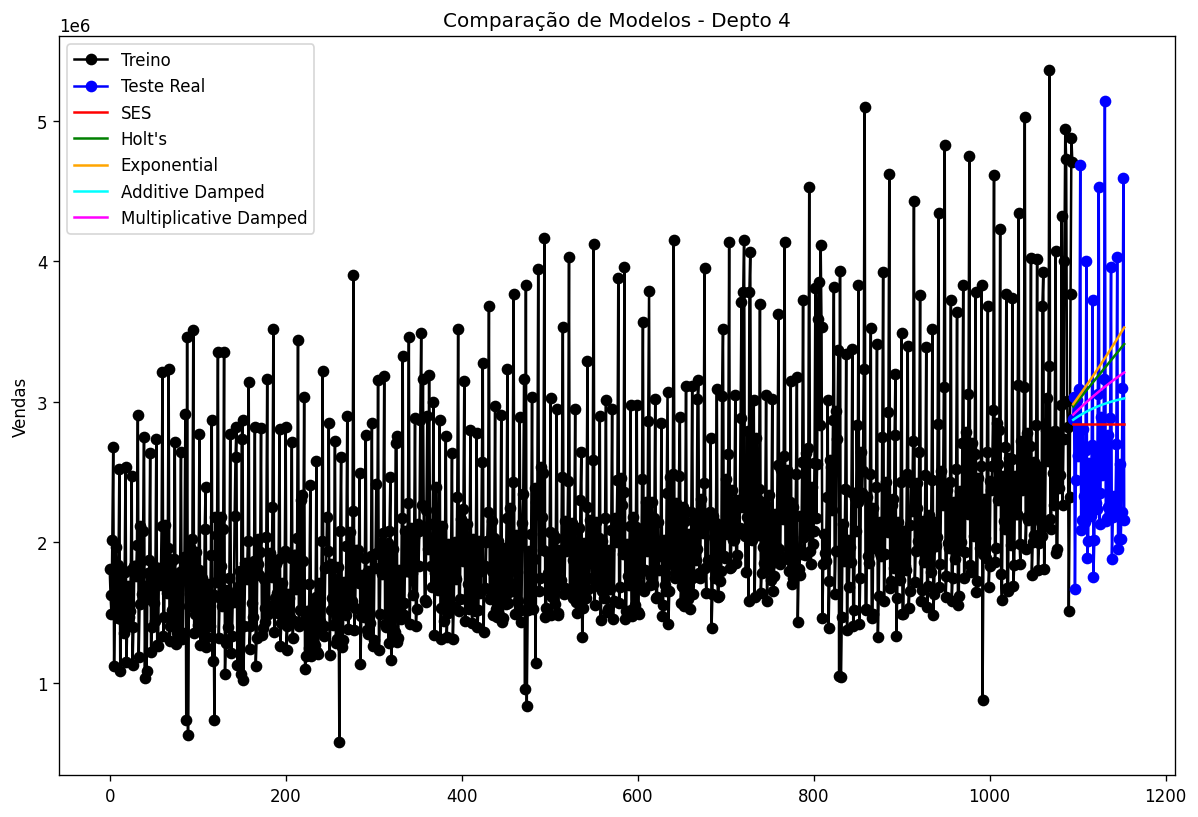

In [ ]:
# Ajustar modelos
fit1 = SimpleExpSmoothing(treino['Vendas'], initialization_method="estimated").fit()
fit2 = Holt(treino['Vendas'], initialization_method="estimated").fit()
fit3 = Holt(treino['Vendas'], exponential=True, initialization_method="estimated").fit()
fit4 = Holt(treino['Vendas'], damped_trend=True, initialization_method="estimated").fit(damping_trend=0.98)
fit5 = Holt(treino['Vendas'], exponential=True, damped_trend=True, initialization_method="estimated").fit()

# Previsões para o período de teste
fcast1 = fit1.forecast(len(teste)).rename("SES")
fcast2 = fit2.forecast(len(teste)).rename("Holt's")
fcast3 = fit3.forecast(len(teste)).rename("Exponential")
fcast4 = fit4.forecast(len(teste)).rename("Additive Damped")
fcast5 = fit5.forecast(len(teste)).rename("Multiplicative Damped")

# Plotando
ax = treino['Vendas'].plot(color="black", marker="o", figsize=(12,8), label="Treino")
teste['Vendas'].plot(ax=ax, color="blue", marker="o", label="Teste Real")
fcast1.plot(ax=ax, color='red', legend=True)
fcast2.plot(ax=ax, color='green', legend=True)
fcast3.plot(ax=ax, color='orange', legend=True)
fcast4.plot(ax=ax, color='cyan', legend=True)
fcast5.plot(ax=ax, color='magenta', legend=True)
ax.set_ylabel('Vendas')
plt.title('Comparação de Modelos - Depto 4')
plt.legend()
plt.show()

**4. HOLT - WINTERS (NÍVEL, TENDÊNCIA E SAZONALIDADE)**

MAE Holt-Winters: 1,509,036
RMSE Holt-Winters: 1,711,079
MAPE Holt-Winters: 55.63%


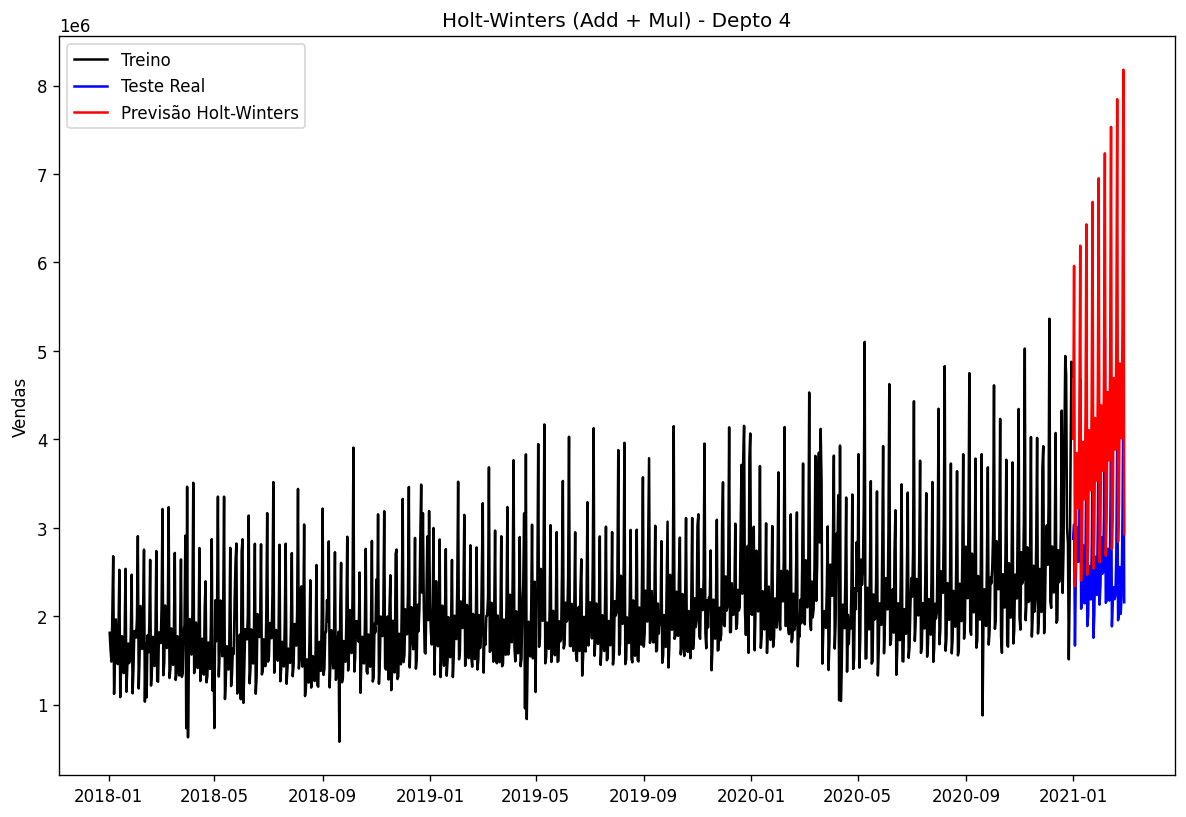

In [ ]:
# Ajustar Holt-Winters (tendência aditiva + sazonalidade multiplicativa)
fit_hw = ExponentialSmoothing(
    treino['Vendas'],
    seasonal_periods=7,   # padrão semanal
    trend='add',
    seasonal='mul',
    use_boxcox=True,      #estabilizar a variância dos dados, contribuindo para um melhor ajuste do modelo.
    initialization_method="estimated"
).fit()

# Previsão para o período de teste
fcast_hw = fit_hw.forecast(len(teste)).rename("Holt-Winters Multiplicativo")

# Comparar com valores reais
resultado_hw = pd.DataFrame({
    'Data': teste['Data_BR'],
    'Real': teste['Vendas'],
    'Previsto': fcast_hw
})

# Métricas de erro
mae_hw = mean_absolute_error(resultado_hw['Real'], resultado_hw['Previsto'])
rmse_hw = np.sqrt(mean_squared_error(resultado_hw['Real'], resultado_hw['Previsto']))
mape_hw = mean_absolute_percentage_error(resultado_hw['Real'], resultado_hw['Previsto'])

print(f"MAE Holt-Winters: {mae_hw:,.0f}")
print(f"RMSE Holt-Winters: {rmse_hw:,.0f}")
print(f"MAPE Holt-Winters: {mape_hw:.2%}")

# Plotando
plt.figure(figsize=(12,8))
plt.plot(treino['Data_BR'], treino['Vendas'], color='black', label='Treino')
plt.plot(teste['Data_BR'], teste['Vendas'], color='blue', label='Teste Real')
plt.plot(teste['Data_BR'], fcast_hw, color='red', label='Previsão Holt-Winters')
plt.title('Holt-Winters (Add + Mul) - Depto 4')
plt.ylabel('Vendas')
plt.legend()
plt.show()

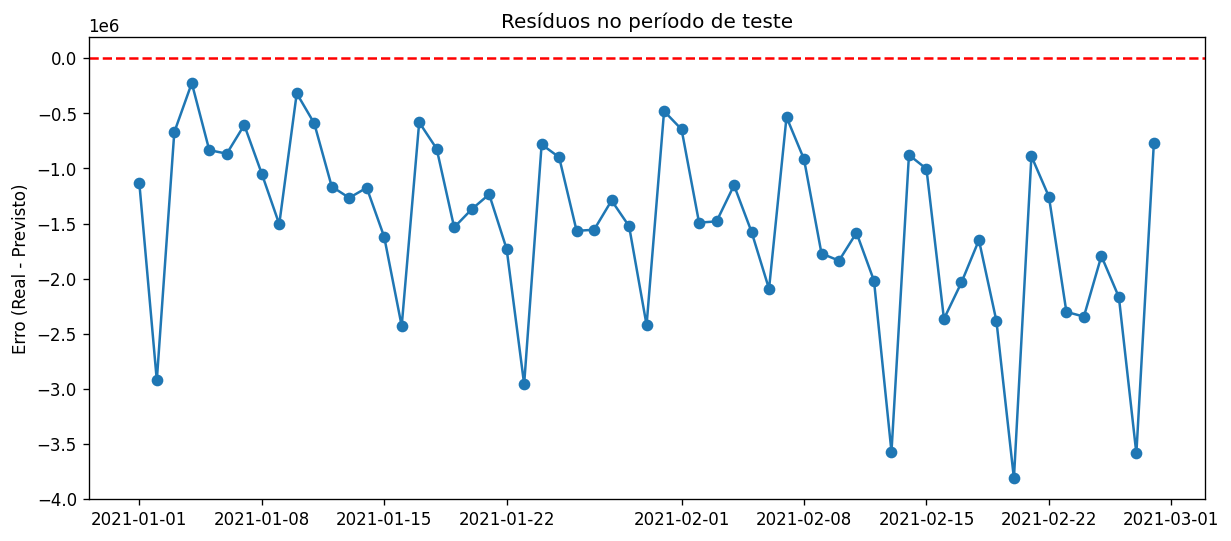

In [ ]:
erro = teste['Vendas'].values - fcast_hw.values

plt.figure(figsize=(12,5))
plt.plot(teste['Data_BR'], erro, marker='o')
plt.axhline(0, color='red', linestyle='--')

plt.title('Resíduos no período de teste')
plt.ylabel('Erro (Real - Previsto)')
plt.show()

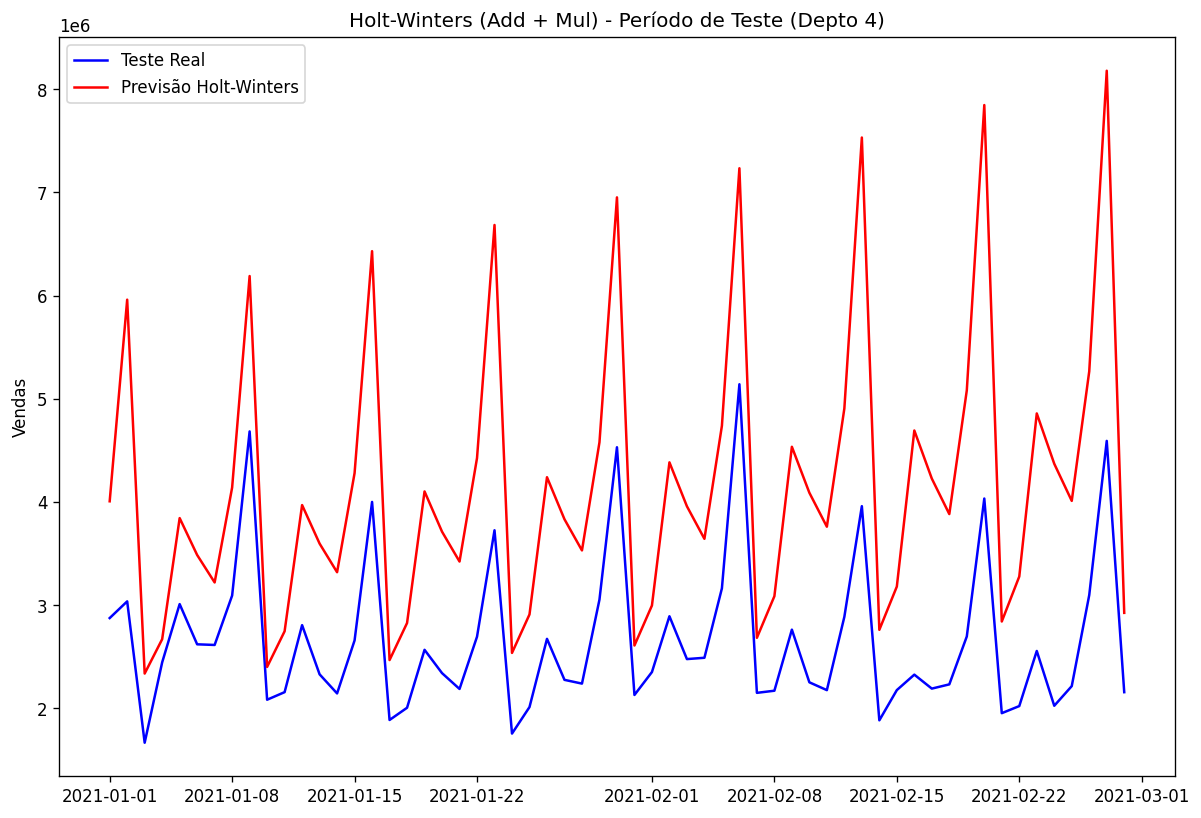

In [ ]:
# Plotando apenas o período de teste
plt.figure(figsize=(12,8))
plt.plot(teste['Data_BR'], teste['Vendas'], color='blue', label='Teste Real')
plt.plot(teste['Data_BR'], fcast_hw, color='red', label='Previsão Holt-Winters')
plt.title('Holt-Winters (Add + Mul) - Período de Teste (Depto 4)')
plt.ylabel('Vendas')
plt.legend()
plt.show()

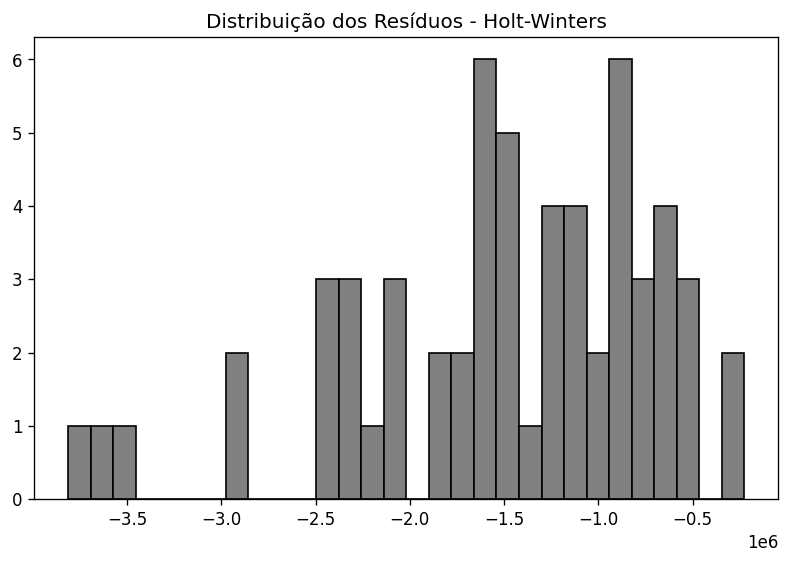

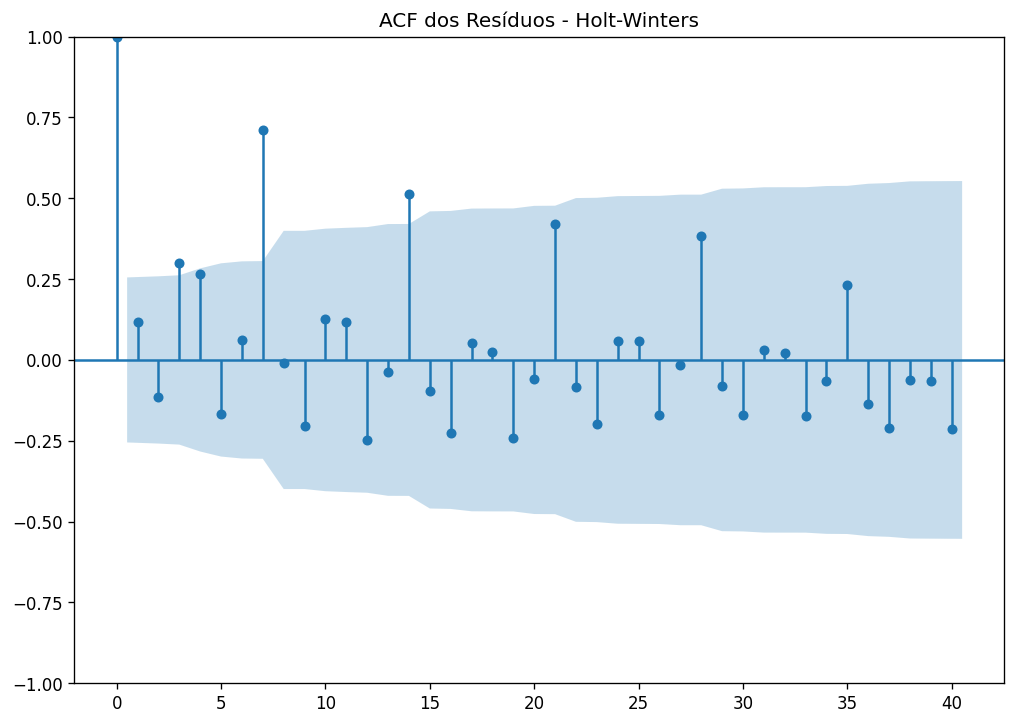

Teste de Ljung-Box - Holt-Winters
Lag 7: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 14: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 21: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)


In [ ]:
# Resíduos = valores reais - previstos
erro = teste['Vendas'].values - fcast_hw.values

# Histograma dos resíduos
plt.figure(figsize=(8,5))
plt.hist(erro, bins=30, color='gray', edgecolor='black')
plt.title("Distribuição dos Resíduos - Holt-Winters")
plt.show()

# ACF dos resíduos
sm.graphics.tsa.plot_acf(erro, lags=40)
plt.title("ACF dos Resíduos - Holt-Winters")
plt.show()

# Teste de Ljung-Box em múltiplos da sazonalidade semanal
ljung_hw = acorr_ljungbox(erro, lags=[7, 14, 21], return_df=True)

print("Teste de Ljung-Box - Holt-Winters")
for lag, row in ljung_hw.iterrows():
    pvalor = row['lb_pvalue']
    if pvalor > 0.05:
        print(f"Lag {lag}: p-valor={pvalor:.4f} → NÃO há autocorrelação (resíduos ~ ruído branco)")
    else:
        print(f"Lag {lag}: p-valor={pvalor:.4f} → Há autocorrelação significativa (modelo não capturou tudo)")

In [ ]:
# Ajustar Holt-Winters (tendência aditiva + sazonalidade multiplicativa)
fit_hw2 = ExponentialSmoothing(
    treino['Vendas'],
    seasonal_periods=7,   # padrão semanal
    trend='add',
    seasonal='mul',
    use_boxcox=True,      #estabilizar a variância dos dados, contribuindo para um melhor ajuste do modelo.
    initialization_method="estimated"
).fit()

fit4 = Holt(treino['Vendas'], damped_trend=True, initialization_method="estimated").fit(damping_trend=0.98)

# Previsão para o período de teste
fcast_hw = fit_hw.forecast(len(teste)).rename("Holt-Winters Multiplicativo")

# Comparar com valores reais
resultado_hw = pd.DataFrame({
    'Data': teste['Data_BR'],
    'Real': teste['Vendas'],
    'Previsto': fcast_hw
})

# Métricas de erro
mae_hw = mean_absolute_error(resultado_hw['Real'], resultado_hw['Previsto'])
rmse_hw = np.sqrt(mean_squared_error(resultado_hw['Real'], resultado_hw['Previsto']))
mape_hw = mean_absolute_percentage_error(resultado_hw['Real'], resultado_hw['Previsto'])

print(f"MAE Holt-Winters: {mae_hw:,.0f}")
print(f"RMSE Holt-Winters: {rmse_hw:,.0f}")
print(f"MAPE Holt-Winters: {mape_hw:.2%}")

# Plotando
plt.figure(figsize=(12,8))
plt.plot(treino['Data_BR'], treino['Vendas'], color='black', label='Treino')
plt.plot(teste['Data_BR'], teste['Vendas'], color='blue', label='Teste Real')
plt.plot(teste['Data_BR'], fcast_hw, color='red', label='Previsão Holt-Winters')
plt.title('Holt-Winters (Add + Mul) - Depto 4')
plt.ylabel('Vendas')
plt.legend()
plt.show()

In [ ]:
print(fit_hw.summary())

                        ExponentialSmoothing Model Results                       
Dep. Variable:                   Vendas   No. Observations:                  1095
Model:             ExponentialSmoothing   SSE                 140060207882358.203
Optimized:                         True   AIC                           28026.169
Trend:                         Additive   BIC                           28081.153
Seasonal:                Multiplicative   AICC                          28026.506
Seasonal Periods:                     7   Date:                  Mon, 06 Jul 2026
Box-Cox:                           True   Time:                          22:52:10
Box-Cox Coeff.:                -0.34849                                          
                          coeff                 code              optimized      
---------------------------------------------------------------------------------
smoothing_level               0.1464227                alpha                 True
smoothing_trend 

**5. COMPARANDO MODELOS**

Métricas de Erro por Modelo:
                  Modelo         MAE        RMSE    MAPE
0                    SES   631475.30   785520.56  0.2448
1                 Holt's   829638.82   935464.11  0.3447
2            Exponential   869822.71   974500.24  0.3640
3        Additive Damped   692266.85   821994.06  0.2768
4  Multiplicative Damped   752099.06   868427.84  0.3071
5             HW Add+Mul  1509036.02  1711078.81  0.5563
6             HW Mul+Add  1321299.96  1359888.05  0.5373
7             HW Add+Add  1339829.95  1378015.33  0.5447
8             HW Mul+Mul  1664332.82  1751111.90  0.6349

Parâmetros Principais dos Modelos:
                         SES    Holt's  Exponential  Additive Damped  \
smoothing_level     0.022725  0.020413     0.020493         0.018873   
smoothing_trend          NaN  0.020413     0.020493         0.018873   
smoothing_seasonal       NaN       NaN          NaN              NaN   
damping_trend            NaN       NaN          NaN         0.980000   

    

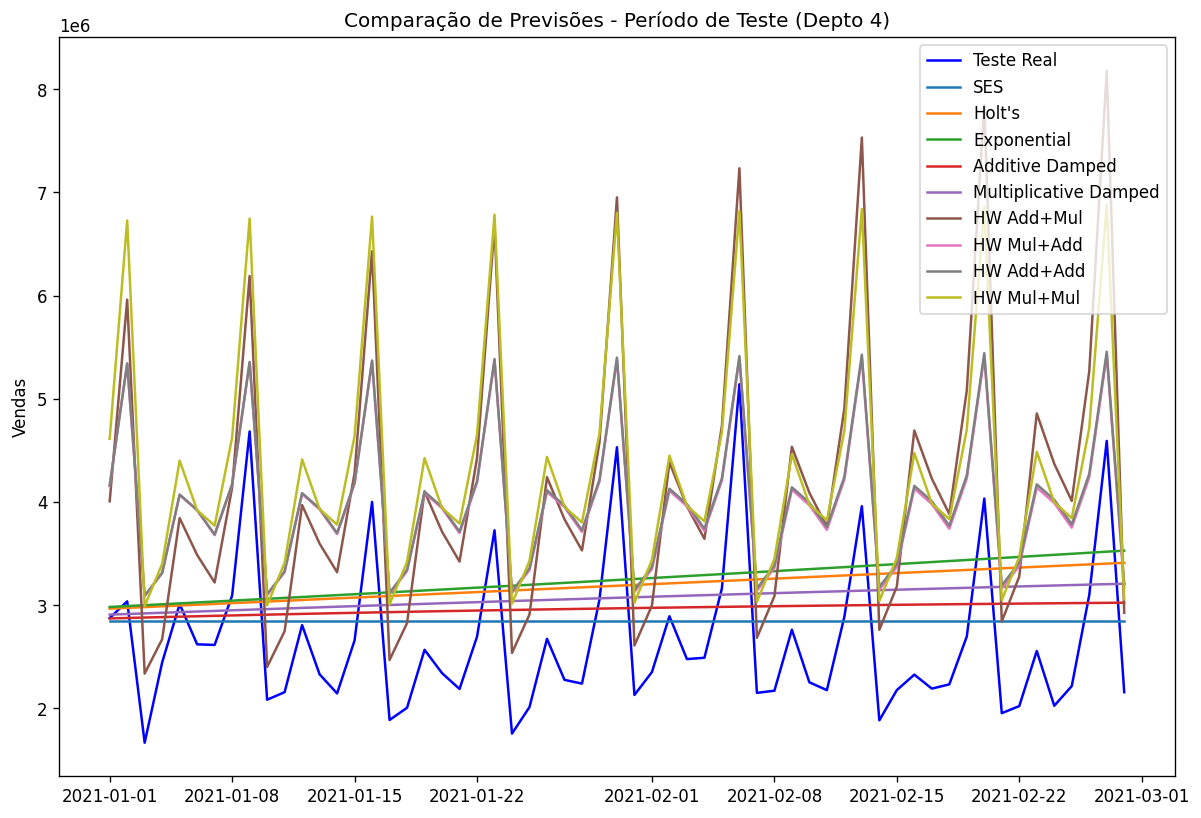

In [ ]:
# SES - Suavização Exponencial Simples
fit1 = SimpleExpSmoothing(treino['Vendas'], initialization_method="estimated").fit()

# Holt - Tendência aditiva
fit2 = Holt(treino['Vendas'], initialization_method="estimated").fit()

# Holt Exponencial - Tendência multiplicativa
fit3 = Holt(treino['Vendas'], exponential=True, initialization_method="estimated").fit()

# Holt Amortecido - Tendência aditiva amortecida
fit4 = Holt(treino['Vendas'], damped_trend=True, initialization_method="estimated").fit(damping_trend=0.98)

# Holt Exponencial Amortecido
fit5 = Holt(treino['Vendas'], exponential=True, damped_trend=True, initialization_method="estimated").fit()

# Holt-Winters - Tendência aditiva + sazonalidade multiplicativa
fit6 = ExponentialSmoothing(
    treino['Vendas'],
    seasonal_periods=7,   # padrão semanal
    trend='add',
    seasonal='mul',
    use_boxcox=True,
    initialization_method="estimated"
).fit()

# Holt-Winters - Tendência multiplicativa + sazonalidade aditiva
fit7 = ExponentialSmoothing(
    treino['Vendas'],
    seasonal_periods=7,
    trend='mul',
    seasonal='add',
    initialization_method="estimated"
).fit()

# Holt-Winters - Tendência aditiva + sazonalidade aditiva
fit8 = ExponentialSmoothing(
    treino['Vendas'],
    seasonal_periods=7,
    trend='add',
    seasonal='add',
    initialization_method="estimated"
).fit()

# Holt-Winters - Tendência multiplicativa + sazonalidade multiplicativa
fit9 = ExponentialSmoothing(
    treino['Vendas'],
    seasonal_periods=7,
    trend='mul',
    seasonal='mul',
    initialization_method="estimated"
).fit()

# Previsões
models = {
    "SES": fit1.forecast(len(teste)),
    "Holt's": fit2.forecast(len(teste)),
    "Exponential": fit3.forecast(len(teste)),
    "Additive Damped": fit4.forecast(len(teste)),
    "Multiplicative Damped": fit5.forecast(len(teste)),
    "HW Add+Mul": fit6.forecast(len(teste)),
    "HW Mul+Add": fit7.forecast(len(teste)),
    "HW Add+Add": fit8.forecast(len(teste)),
    "HW Mul+Mul": fit9.forecast(len(teste))
}

# Calcular métricas de erro
results = []
for name, forecast in models.items():
    mae = mean_absolute_error(teste['Vendas'], forecast)
    rmse = np.sqrt(mean_squared_error(teste['Vendas'], forecast))
    mape = mean_absolute_percentage_error(teste['Vendas'], forecast)
    results.append([name, round(mae, 2), round(rmse, 2), round(mape, 4)])

df_results = pd.DataFrame(results, columns=["Modelo", "MAE", "RMSE", "MAPE"])
print("Métricas de Erro por Modelo:")
print(df_results)

# Parâmetros principais
params = ['smoothing_level', 'smoothing_trend', 'smoothing_seasonal', 'damping_trend']

df_params = pd.DataFrame({
    "SES": [fit1.params.get(p, None) for p in params],
    "Holt's": [fit2.params.get(p, None) for p in params],
    "Exponential": [fit3.params.get(p, None) for p in params],
    "Additive Damped": [fit4.params.get(p, None) for p in params],
    "Multiplicative Damped": [fit5.params.get(p, None) for p in params],
    "HW Add+Mul": [fit6.params.get(p, None) for p in params],
    "HW Mul+Add": [fit7.params.get(p, None) for p in params],
    "HW Add+Add": [fit8.params.get(p, None) for p in params],
    "HW Mul+Mul": [fit9.params.get(p, None) for p in params],
}, index=params)

print("\nParâmetros Principais dos Modelos:")
print(df_params)

# Plot comparativo
plt.figure(figsize=(12,8))
plt.plot(teste['Data_BR'], teste['Vendas'], color='blue', label='Teste Real')
for name, forecast in models.items():
    plt.plot(teste['Data_BR'], forecast, label=name)
plt.title('Comparação de Previsões - Período de Teste (Depto 4)')
plt.ylabel('Vendas')
plt.legend()
plt.show()


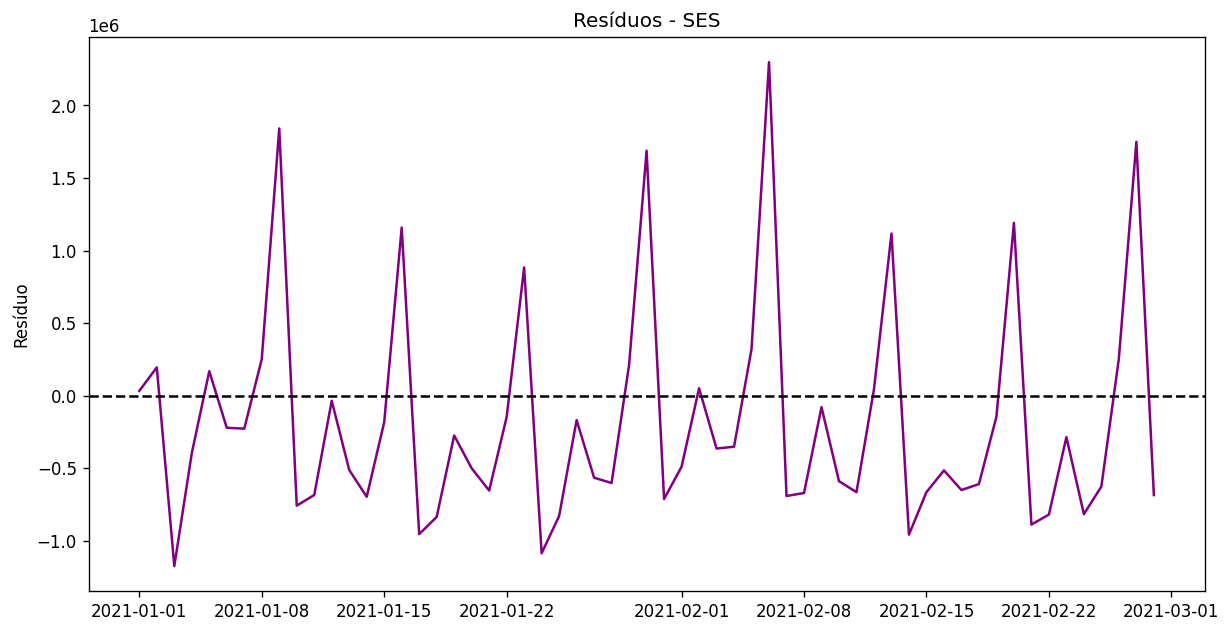

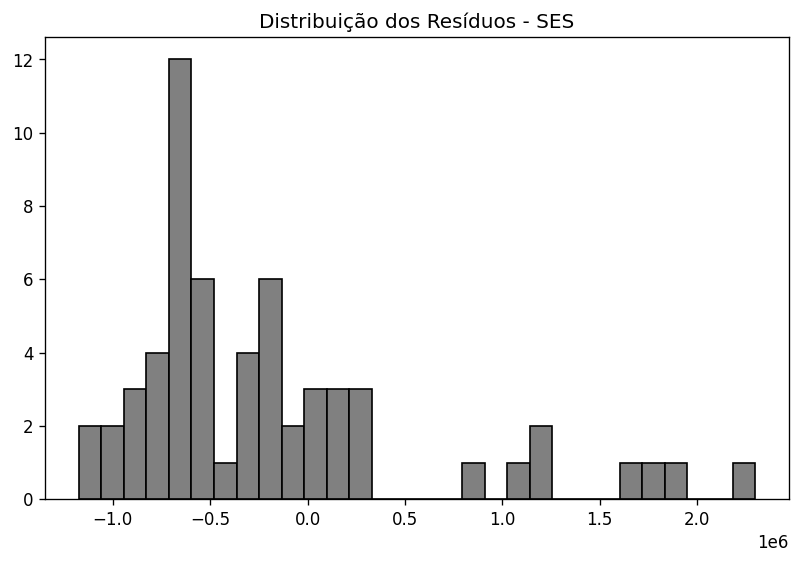

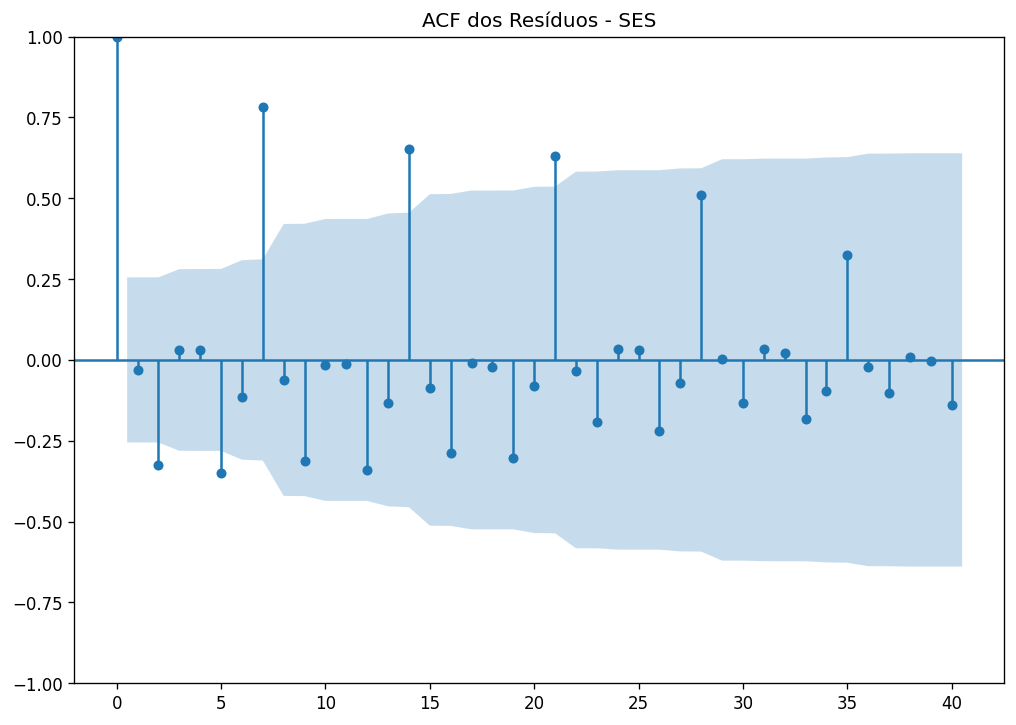

Teste de Ljung-Box - SES
Lag 7: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 14: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 21: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)




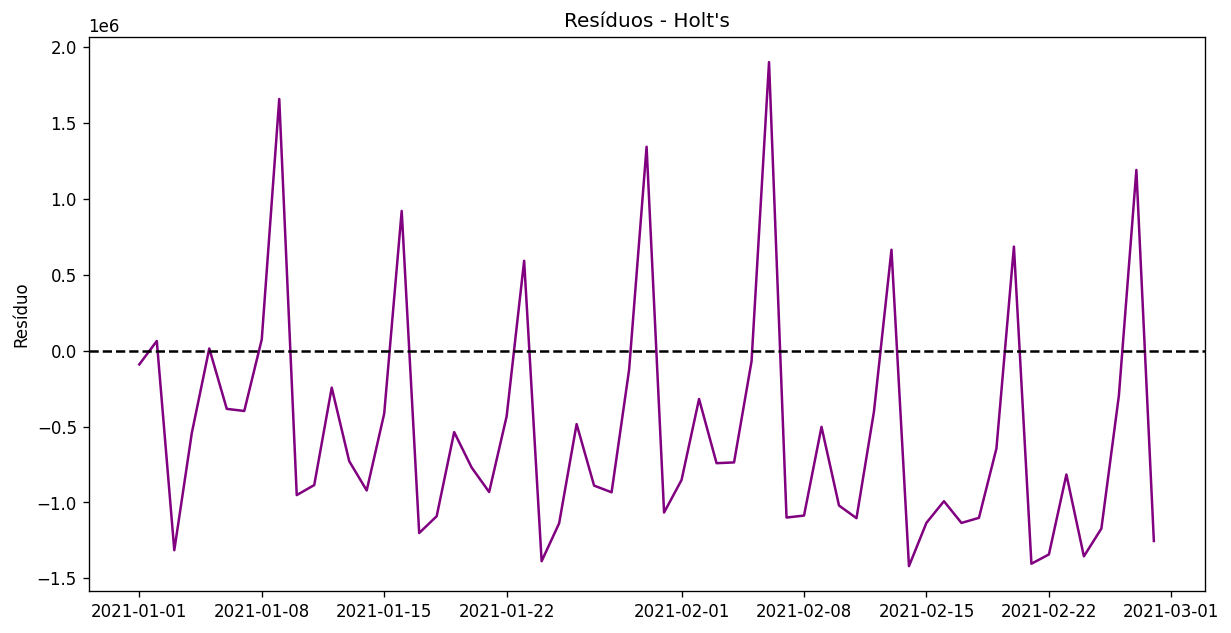

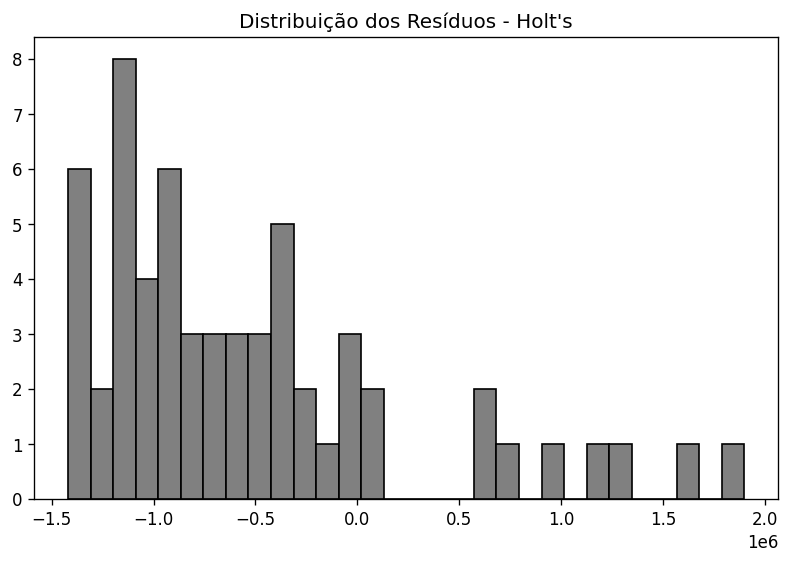

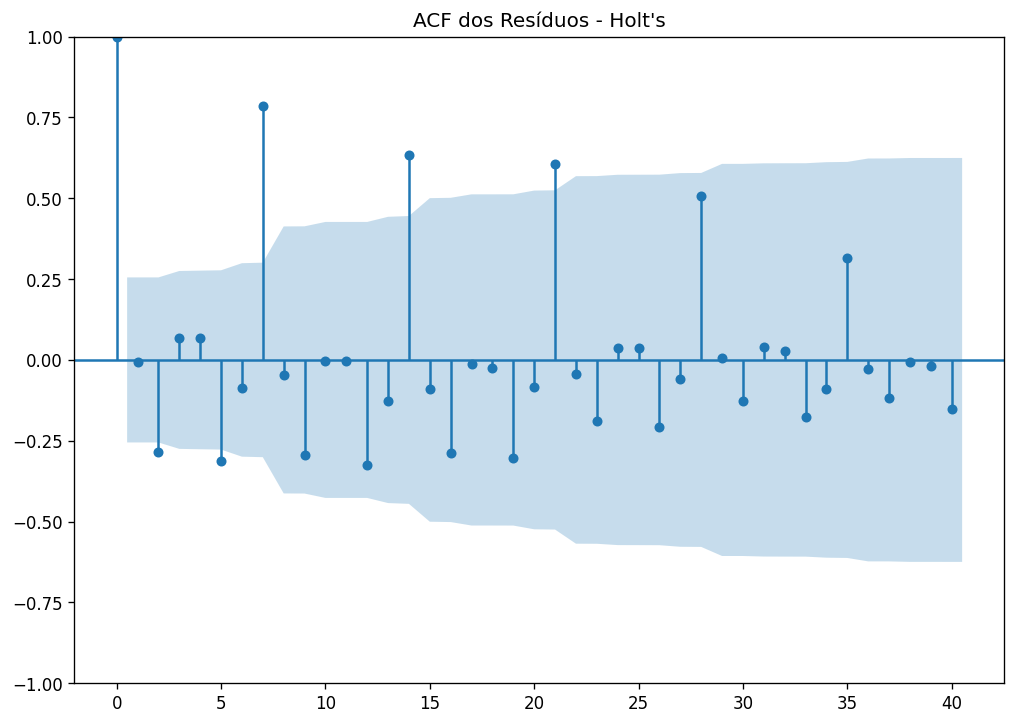

Teste de Ljung-Box - Holt's
Lag 7: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 14: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 21: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)




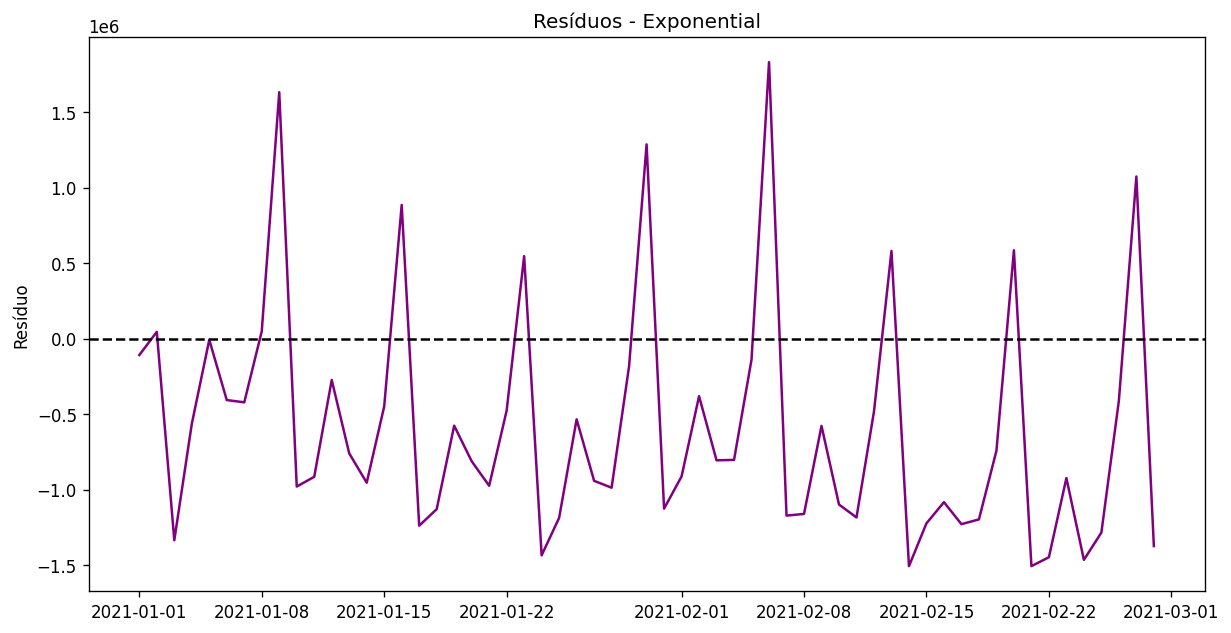

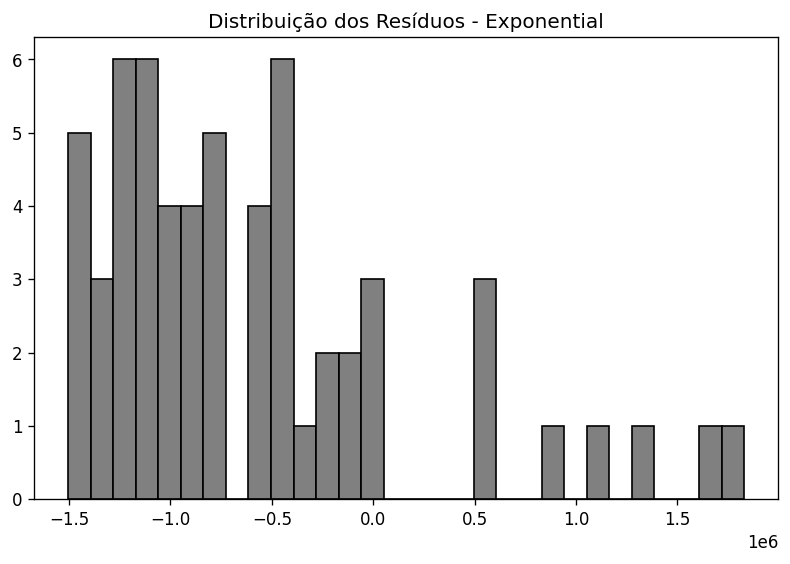

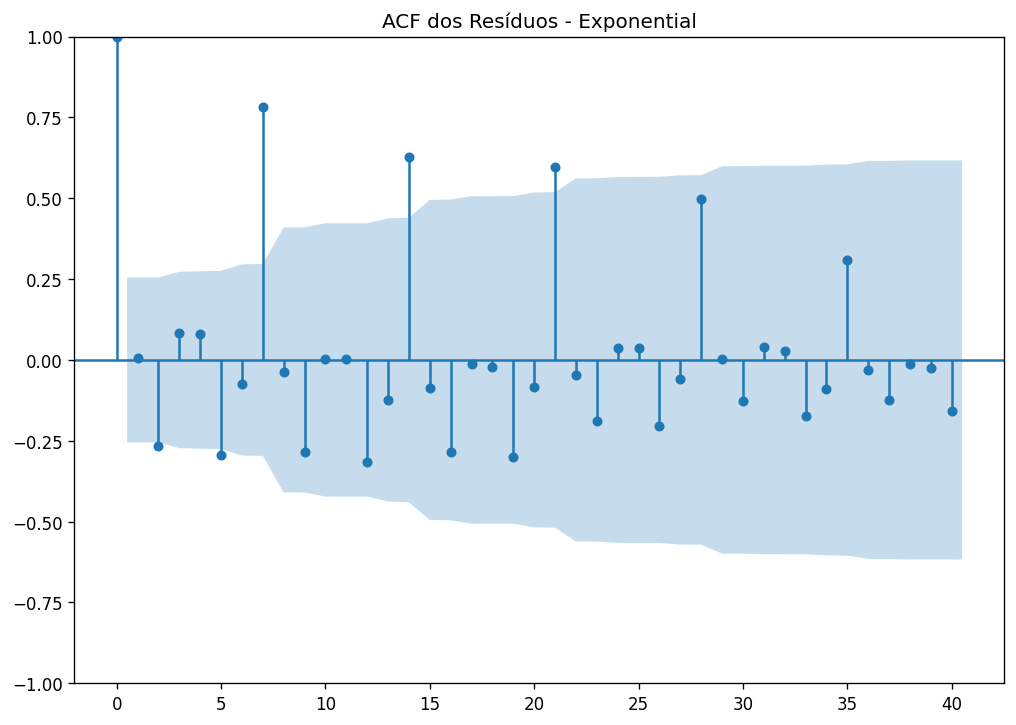

Teste de Ljung-Box - Exponential
Lag 7: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 14: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 21: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)




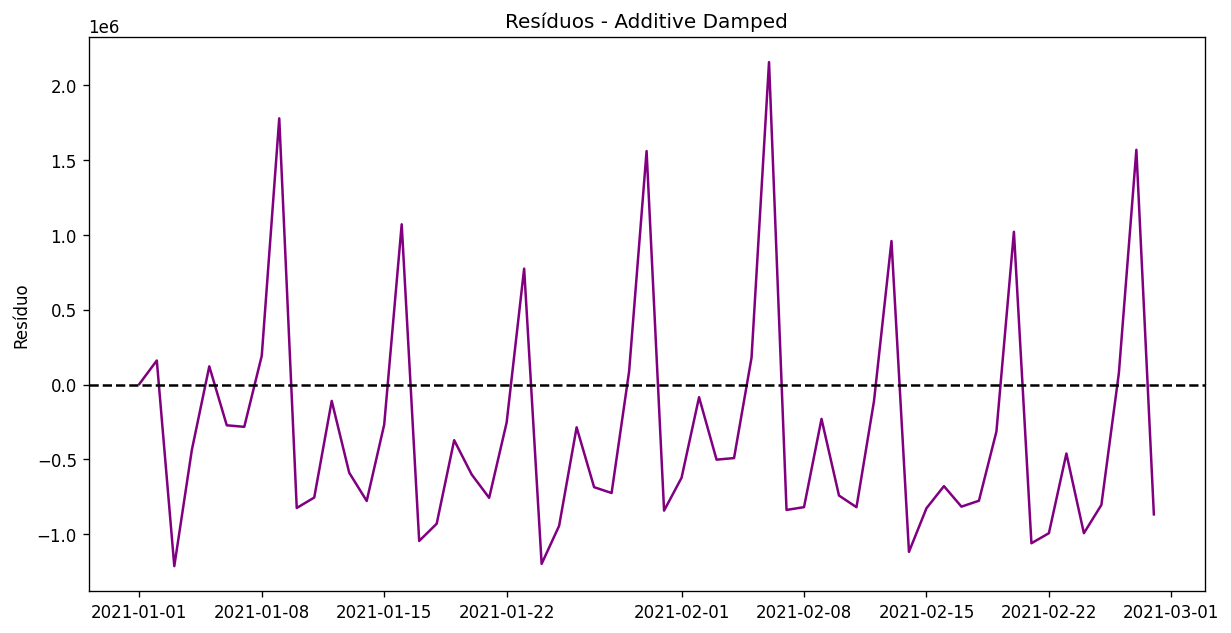

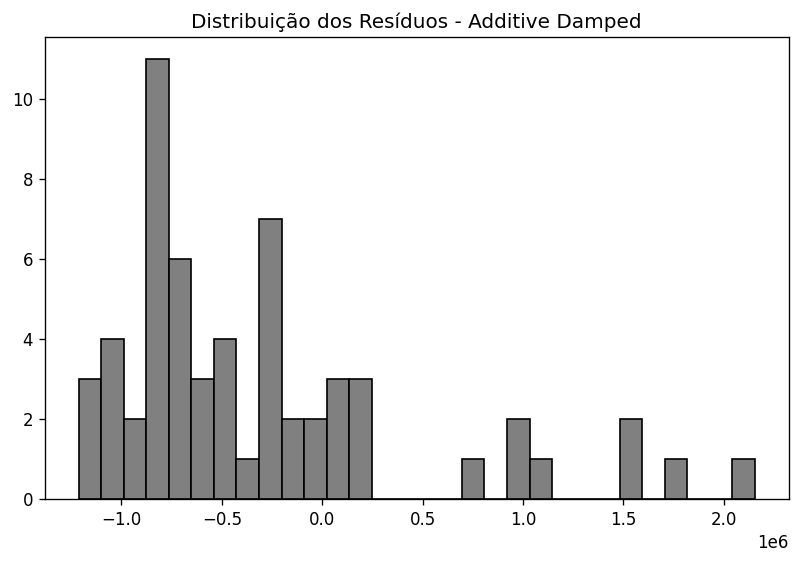

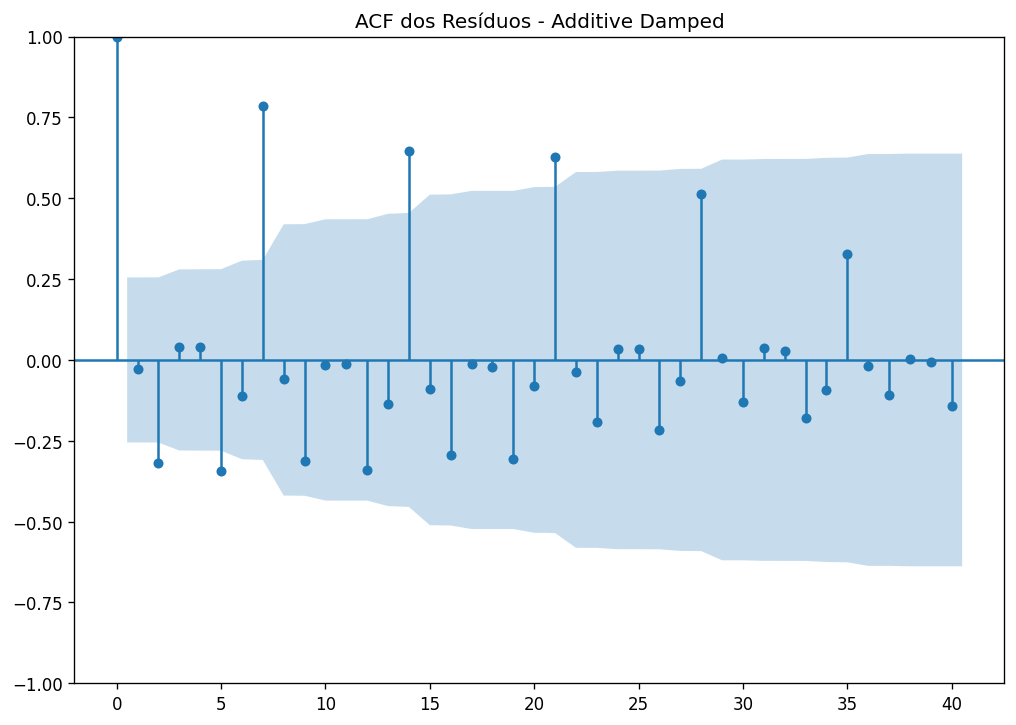

Teste de Ljung-Box - Additive Damped
Lag 7: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 14: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 21: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)




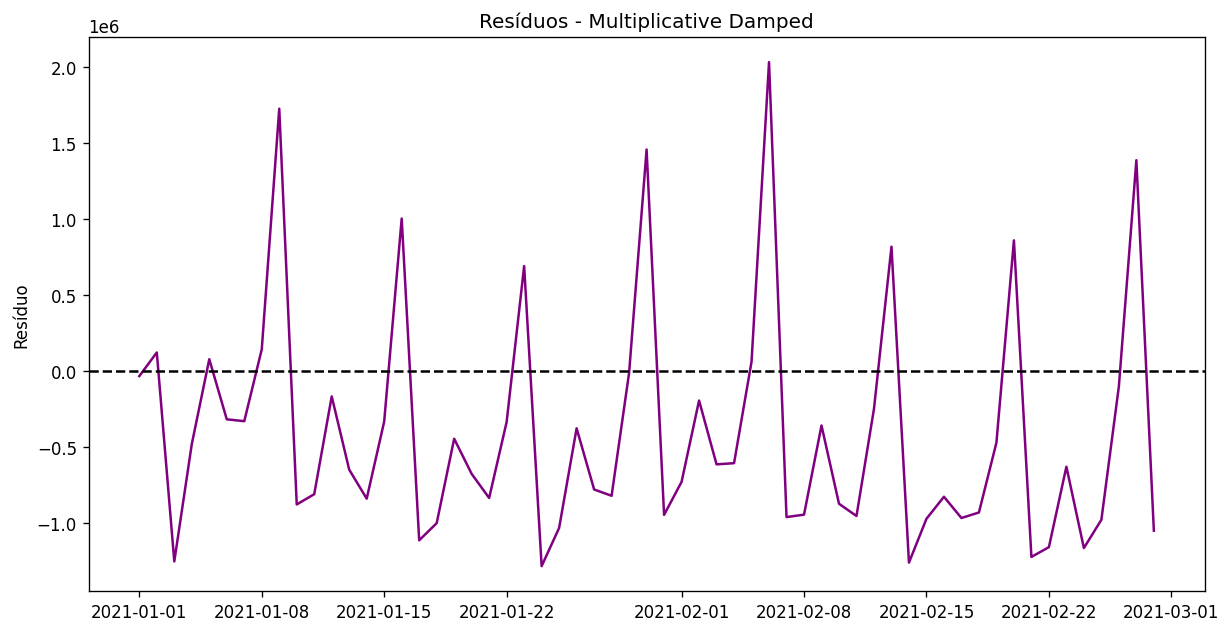

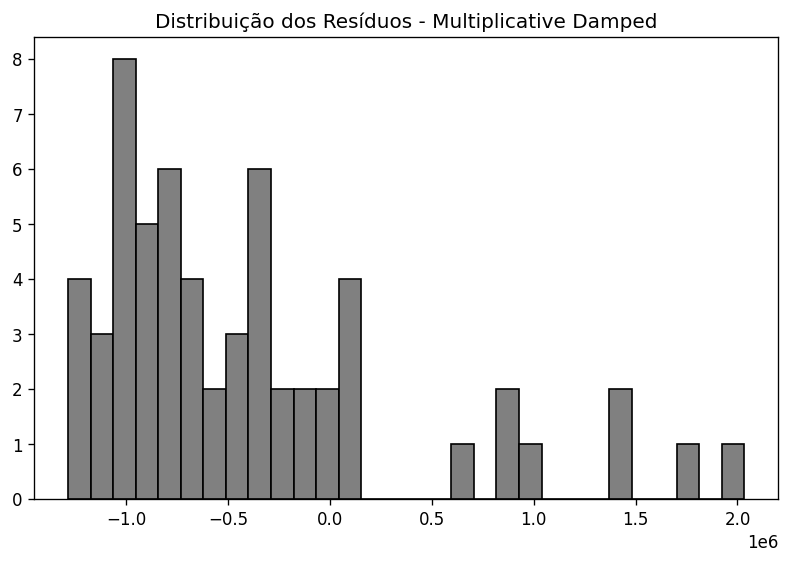

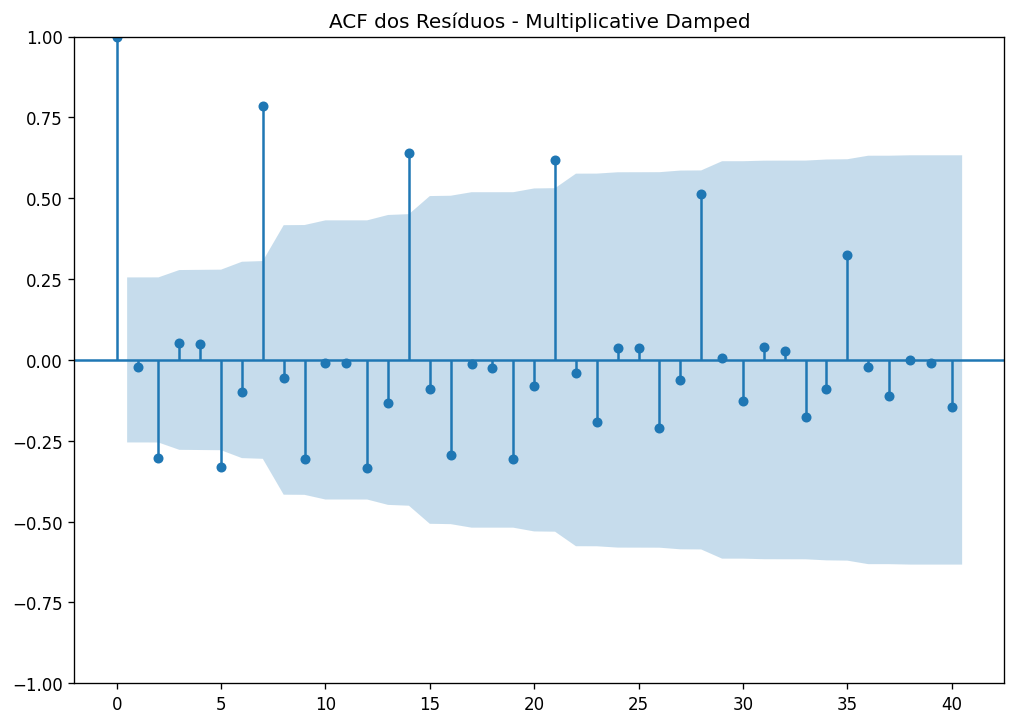

Teste de Ljung-Box - Multiplicative Damped
Lag 7: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 14: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 21: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)




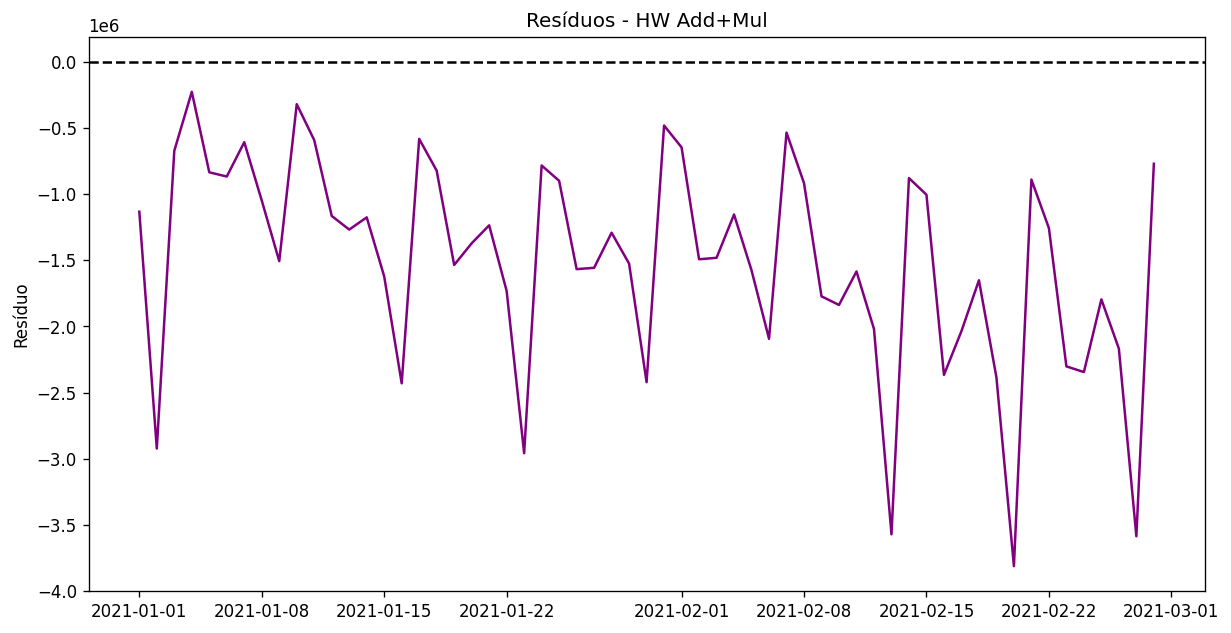

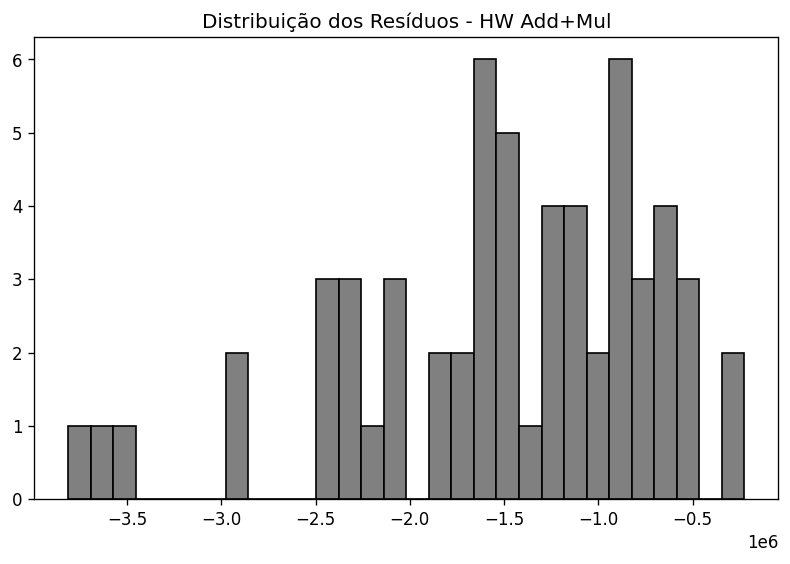

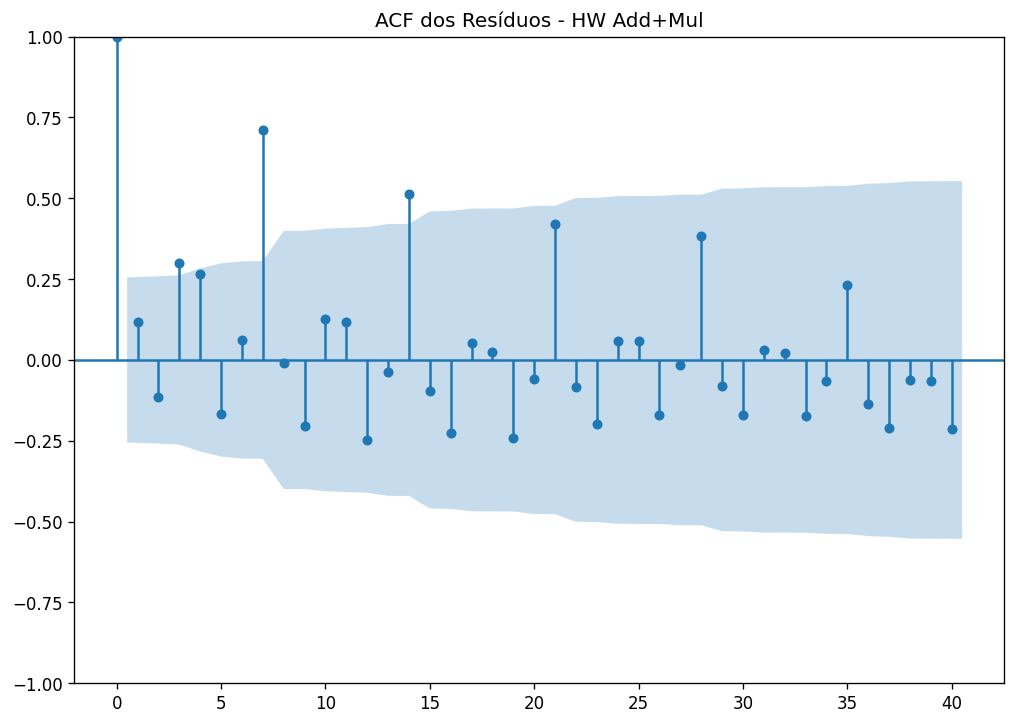

Teste de Ljung-Box - HW Add+Mul
Lag 7: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 14: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 21: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)




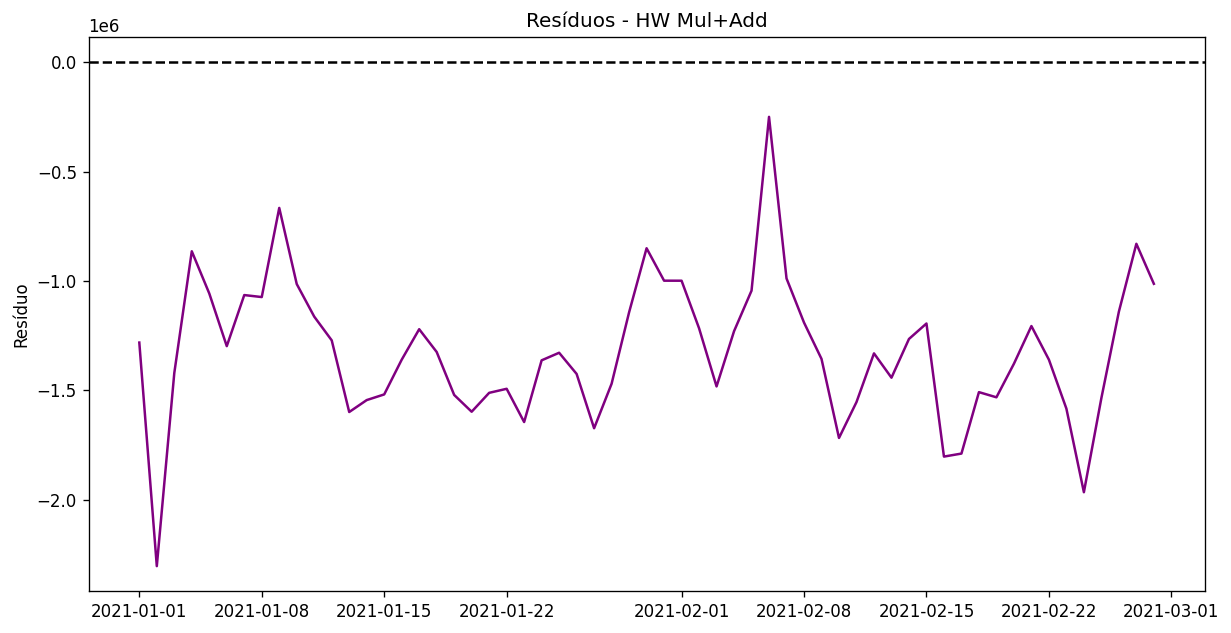

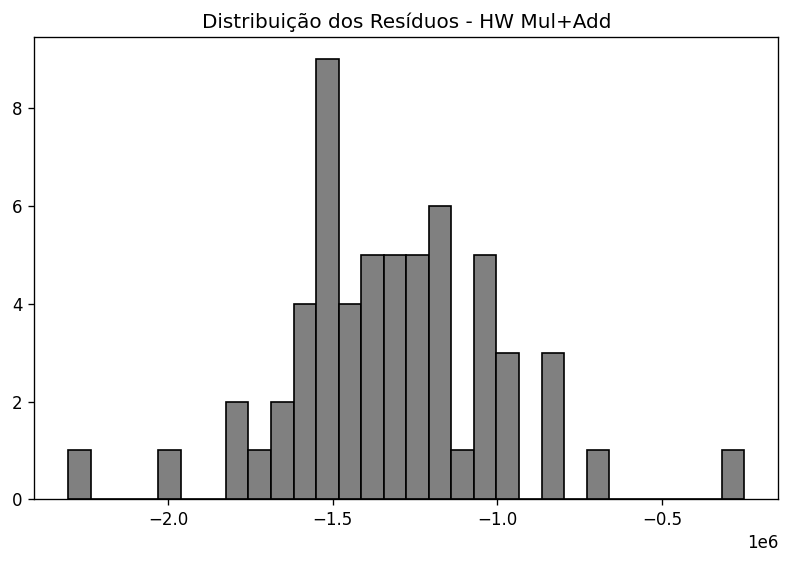

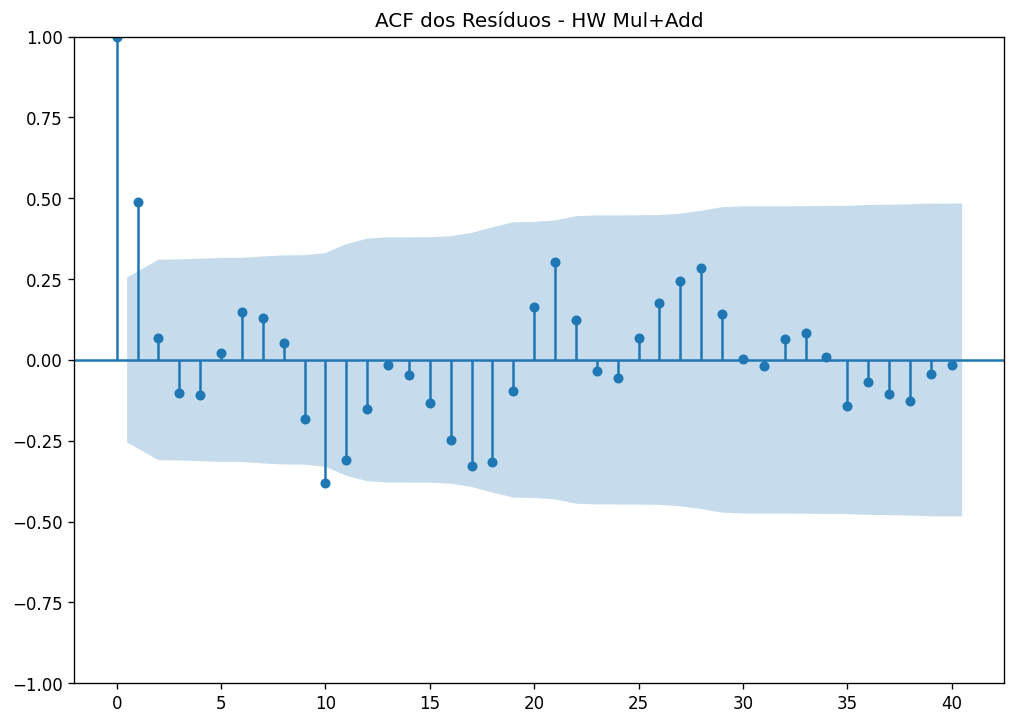

Teste de Ljung-Box - HW Mul+Add
Lag 7: p-valor=0.0078 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 14: p-valor=0.0001 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 21: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)




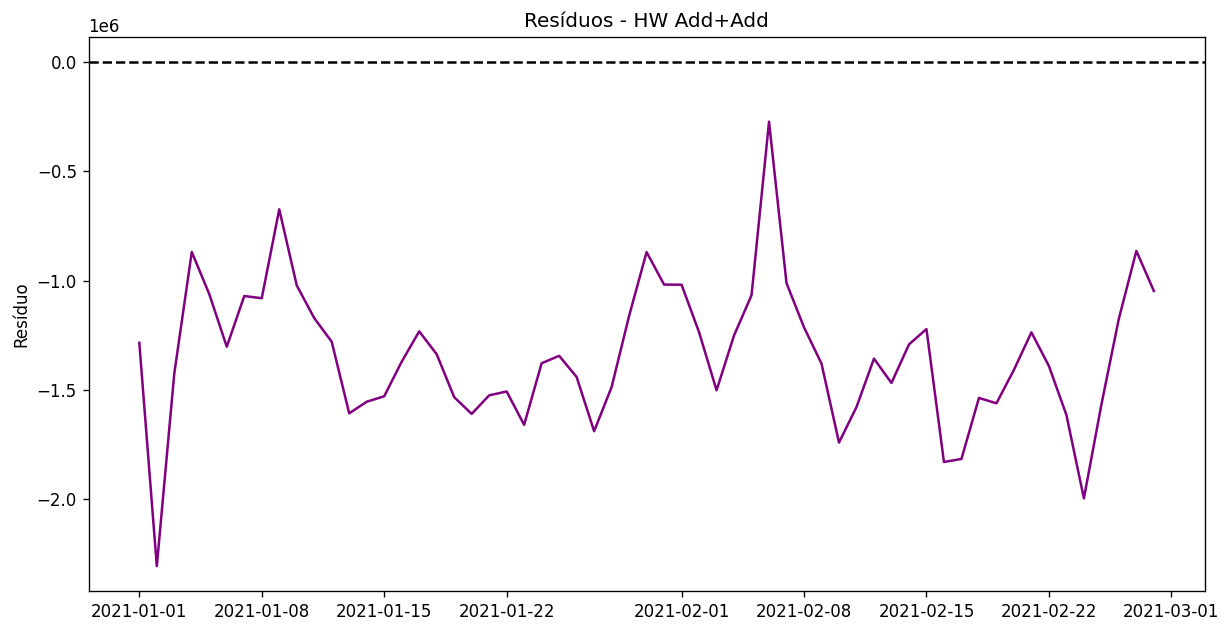

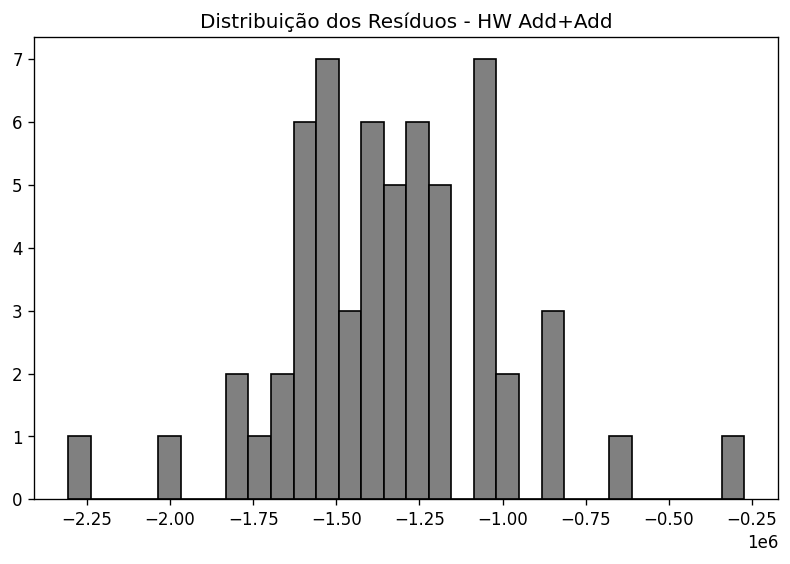

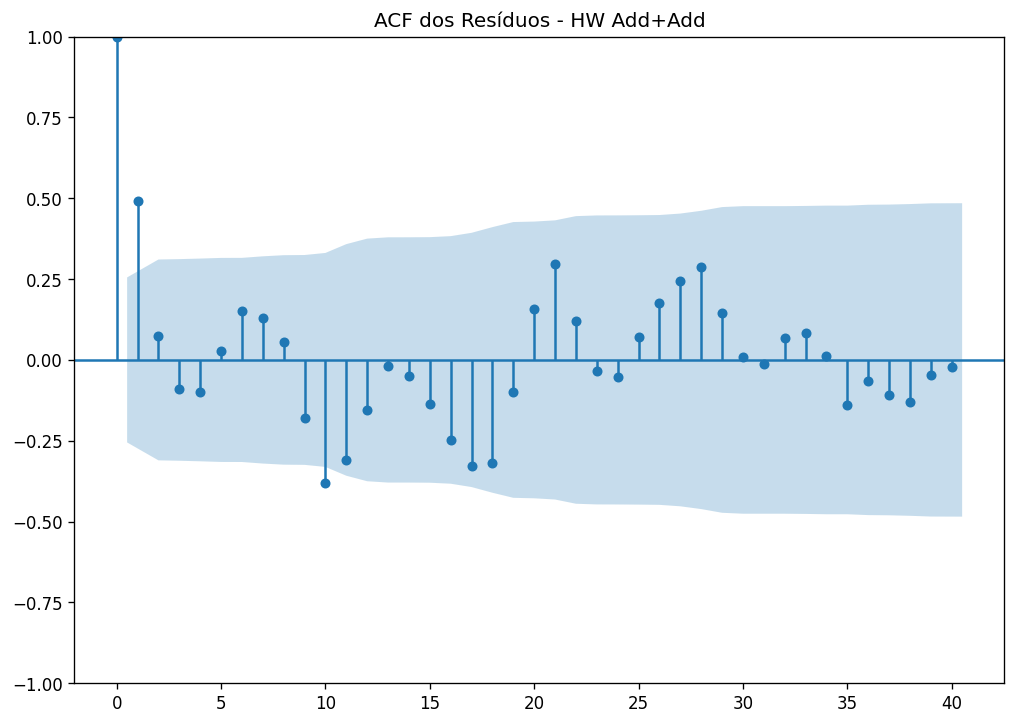

Teste de Ljung-Box - HW Add+Add
Lag 7: p-valor=0.0074 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 14: p-valor=0.0001 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 21: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)




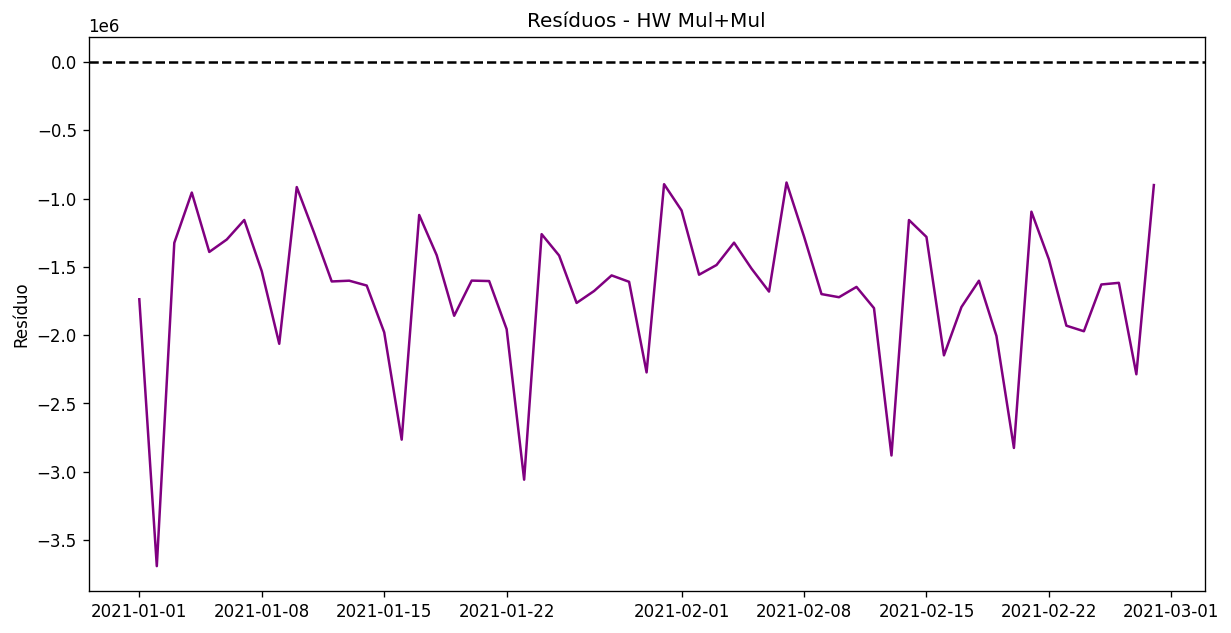

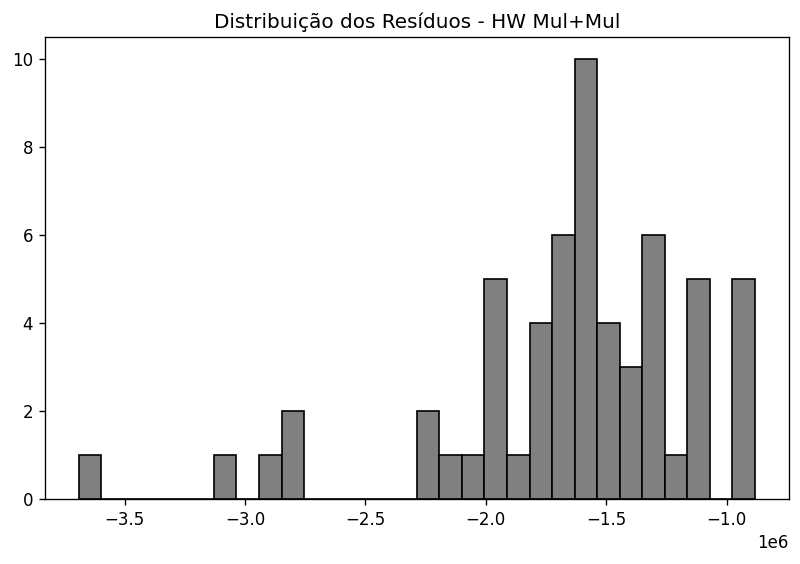

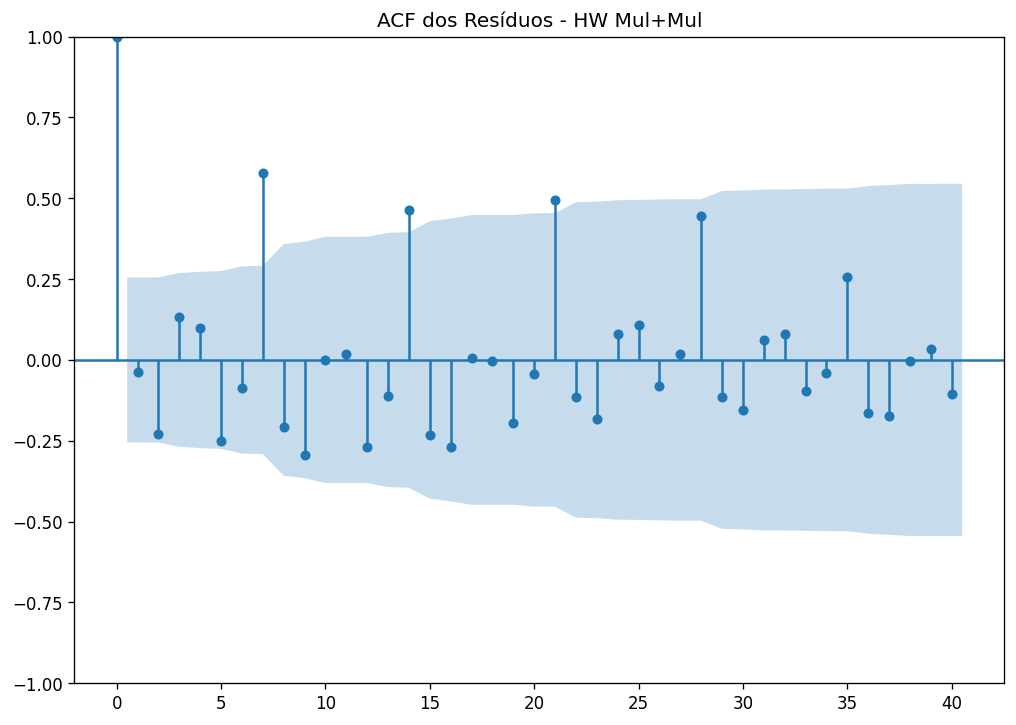

Teste de Ljung-Box - HW Mul+Mul
Lag 7: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 14: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)
Lag 21: p-valor=0.0000 → Há autocorrelação significativa (modelo não capturou tudo)




In [ ]:
# Estudo de Resíduos

def analisar_residuos(nome, real, previsto):
    # Calcular resíduos
    residuos = real - previsto

    # Plot temporal
    plt.figure(figsize=(12,6))
    plt.plot(teste['Data_BR'], residuos, color='purple')
    plt.axhline(0, color='black', linestyle='--')
    plt.title(f"Resíduos - {nome}")
    plt.ylabel("Resíduo")
    plt.show()

    # Histograma
    plt.figure(figsize=(8,5))
    plt.hist(residuos, bins=30, color='gray', edgecolor='black')
    plt.title(f"Distribuição dos Resíduos - {nome}")
    plt.show()

    # ACF
    sm.graphics.tsa.plot_acf(residuos, lags=40)
    plt.title(f"ACF dos Resíduos - {nome}")
    plt.show()

    # Teste de Ljung-Box (lags múltiplos da sazonalidade semanal)
    ljung = acorr_ljungbox(residuos, lags=[7, 14, 21], return_df=True)
    print(f"Teste de Ljung-Box - {nome}")
    for lag, row in ljung.iterrows():
        pvalor = row['lb_pvalue']
        if pvalor > 0.05:
            print(f"Lag {lag}: p-valor={pvalor:.4f} → NÃO há autocorrelação (resíduos ~ ruído branco)")
        else:
            print(f"Lag {lag}: p-valor={pvalor:.4f} → Há autocorrelação significativa (modelo não capturou tudo)")
    print("\n")

# ============================
# 8. Rodar análise para todos os modelos
# ============================
for nome, forecast in models.items():
    analisar_residuos(nome, teste['Vendas'], forecast)